# Movement Time vs Coherence — layered analysis

## The scientific question

Mice view a random-dot-motion stimulus: a fraction of dots agree on direction (**coherence**), the rest move randomly. The mouse decides left or right and runs to the matching reward port.

**Does the time to physically run depend on (a) how easy the trial was and (b) whether the mouse got it right?** If wrong trials on *easy* stimuli show *longer* movement times than correct trials, this is the **change-of-mind signature** — evidence that the brain's ongoing certainty is reflected in motor execution, not just locked in before movement begins.

## Data structure

One row per (trial × epoch). Each trial is split into named time-slices:

```
Wait Trial Start → Sampling (watching dots) → Movement to Lateral Port (running) → Reward / Punishment
```

Key columns: `Name` (mouse), `Date`, `SessionNum`, `TrialNumber`, `DV` (signed coherence, −1 to 1), `ChoiceCorrect` (1/0).

## Cohort

**GP4 cohort** — 6 mice (`GP4-23`…`GP4-85`), all L2/3 calcium imaging, 23 separate 2P sessions total.


# 1. Data Loading & Preprocessing

## 1.1 Load raw behavioral data

Open the 2P-filtered pickle (per-trial × per-epoch table). Contains all epoch-level data: movement-port durations, sampling durations, choice correctness, coherence, and mouse/session/trial IDs.

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd()
DATA_FP = HERE / "paper_fast_slow-main" / "data" / "2p" / "df_all_by_epoch_df_f_filtered.pkl"

with open(DATA_FP, "rb") as f:
    df = pickle.load(f)

print(f"rows (trial × epoch): {len(df):,}")
print(f"unique epochs: {sorted(df.epoch.unique())}")
print(f"unique mice: {sorted(df.Name.unique())}")


/sessions/vigilant-hopeful-fermi/tmp/ipykernel_8/109884239.py:12: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  df = pickle.load(f)


rows (trial × epoch): 22,468
unique epochs: ['Decision Time', 'Feedback Wait', 'Movement to Lateral Port', 'Punishment', 'Reward', 'Sampling', 'Wait Trial Start']
unique mice: ['GP4-23', 'GP4-24', 'GP4-28', 'GP4-80', 'GP4-81', 'GP4-85']


~22,000 (trial × epoch) rows from 6 GP4 mice. Each trial contributes one row per epoch.

In [2]:
# ── Global constants and utility definitions ─────────────────────────────────
BIN_EDGES    = np.array([0.0, 1/3, 2/3, 1.01])
BIN_MIDS_PCT = (BIN_EDGES[:-1] + np.minimum(BIN_EDGES[1:], 1.0)) / 2 * 100
BIN_LABELS   = [f"{lo*100:.0f}-{min(hi,1.0)*100:.0f}%"
                for lo, hi in zip(BIN_EDGES[:-1], BIN_EDGES[1:])]
DIFF_NAMES   = ["Hard", "Medium", "Easy"]   # bin 0 = low coherence (hard)

STALL_THRESH = 4.5
TRIAL_KEY    = ["Name", "Date", "SessionNum", "TrialNumber"]
SESSION_KEY  = ["Name", "Date", "SessionNum"]
COLORS       = {"All": "blue", "Correct": "limegreen", "False": "red"}

# Trim method functions — defined early so Section 1.3 dedup cell can use them
def percentile_cutoffs(s, lo=1, hi=99):
    return np.percentile(s, lo), np.percentile(s, hi)

def zscore_cutoffs(s, k=3):
    m, sd = s.mean(), s.std(ddof=1)
    return m - k*sd, m + k*sd

def mad_cutoffs(s, k=3):
    med = np.median(s)
    mad = np.median(np.abs(s - med)) * 1.4826
    return med - k*mad, med + k*mad

def iqr_cutoffs(s, k=1.5):
    q1, q3 = np.percentile(s, [25, 75])
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

trim_methods = {
    "percentile (1st-99th)":         percentile_cutoffs,
    "z-score (mean +/- 3 std)":      zscore_cutoffs,
    "MAD (median +/- 3 MAD)":        mad_cutoffs,
    "Tukey (Q1-1.5IQR, Q3+1.5IQR)": iqr_cutoffs,
}
trim_colors = {
    "percentile (1st-99th)":         "black",
    "z-score (mean +/- 3 std)":      "tab:red",
    "MAD (median +/- 3 MAD)":        "tab:green",
    "Tukey (Q1-1.5IQR, Q3+1.5IQR)": "tab:purple",
}
print("Constants defined. BIN_LABELS:", BIN_LABELS)


Constants defined. BIN_LABELS: ['0-33%', '33-67%', '67-100%']


## 1.2 Exclusion criteria (sampling time > 4.5s)

The Sampling epoch is where the mouse watches the dots before committing to a choice (typically 0.7–1.3 s). Trials lasting >4.5 s indicate inattention. The sampling epoch duration is merged onto each movement-port row via `(Name, Date, SessionNum, TrialNumber)` and a `stalled` boolean column is added.

In [3]:
TRIAL_KEY = ["Name", "Date", "SessionNum", "TrialNumber"]
samp = (df[df.epoch == "Sampling"][TRIAL_KEY + ["epoch_time"]]
        .rename(columns={"epoch_time": "SamplingTime"}))

mv = df[df.epoch == "Movement to Lateral Port"].copy()
mv = mv[mv.ChoiceCorrect.notnull()]
mv["MT"] = mv.epoch_time
mv["DVabs"] = mv.DV.abs()
mv = mv.merge(samp, on=TRIAL_KEY, how="left")
STALL_THRESH = 4.5
mv["stalled"] = mv.SamplingTime > STALL_THRESH
mv["Bin"] = pd.cut(mv.DVabs, BIN_EDGES, include_lowest=True, labels=False).astype(int)

print(f"total trials: {len(mv):,}")
print(f"stalled (>{STALL_THRESH}s in Sampling): {mv.stalled.sum()} ({mv.stalled.mean()*100:.1f}%)")
print(f"unique 2P sessions: {mv[['Name','Date','SessionNum']].drop_duplicates().shape[0]}")


total trials: 5,408
stalled (>4.5s in Sampling): 71 (1.3%)
unique 2P sessions: 23


**71 stalled trials (~1.3%)** flagged for exclusion. **23 unique 2P sessions** confirmed across the 6 mice.

## 1.3 Merge sessions, verify deduplication

In [4]:
# Duplication check: deduplicate samp before merging
samp_dedup = (df[df.epoch == "Sampling"][TRIAL_KEY + ["epoch_time"]]
              .rename(columns={"epoch_time": "SamplingTime"})
              .groupby(TRIAL_KEY, as_index=False)["SamplingTime"].mean())

mv_check = df[df.epoch == "Movement to Lateral Port"].copy()
mv_check = mv_check[mv_check.ChoiceCorrect.notnull()]
mv_check["MT"] = mv_check.epoch_time
mv_check["DVabs"] = mv_check.DV.abs()
mv_check = mv_check.merge(samp_dedup, on=TRIAL_KEY, how="left")
mv_check["stalled"] = mv_check.SamplingTime > STALL_THRESH
mv_check["Bin"] = pd.cut(mv_check.DVabs, BIN_EDGES, include_lowest=True, labels=False).astype(int)

print(f"Duplication check — trials before dedup merge: {len(mv):,}, after: {len(mv_check):,}")
if len(mv_check) != len(mv):
    print("  WARNING: duplication found — using deduped version below.")
else:
    print("  OK: no duplication detected.")

_clean_c = mv_check[~mv_check.stalled]
cutoffs_c = {name: _clean_c.groupby("Bin")["MT"].apply(
                 lambda s, fn=fn: pd.Series(fn(s), index=["lo", "hi"])).unstack()
              for name, fn in trim_methods.items()}
cutoffs_pct = list(cutoffs_c.values())[0]  # percentile 1st-99th

Duplication check — trials before dedup merge: 5,408, after: 5,408
  OK: no duplication detected.


In [5]:
# ── Create mv_trim_c (primary trimmed analysis dataframe) ───────────────────
mv_clean_c = mv_check[~mv_check.stalled].copy()

def _within_cutoffs_c(g):
    lo_c, hi_c = cutoffs_pct.loc[g.name, "lo"], cutoffs_pct.loc[g.name, "hi"]
    return g[(g.MT >= lo_c) & (g.MT <= hi_c)]

mv_trim_c = mv_clean_c.groupby("Bin", group_keys=False).apply(
    _within_cutoffs_c, include_groups=False)
mv_trim_c["Bin"] = pd.cut(mv_trim_c.DVabs, BIN_EDGES, include_lowest=True, labels=False).astype(int)

print(f"mv_trim_c: {len(mv_trim_c):,} trials (stalled removed, 1st-99th pct trimmed per bin)")
print(f"Sessions:  {mv_trim_c[SESSION_KEY].drop_duplicates().shape[0]}")


mv_trim_c: 5,231 trials (stalled removed, 1st-99th pct trimmed per bin)
Sessions:  23


No duplication detected — the merge is clean. `mv_trim_c` (primary analysis dataframe) is ready for use throughout Sections 3–5.

Two mouse cohorts are flagged for attention throughout the analysis. Mouse **GP4-28**, session 2022-03-25 s1 (n=115 trials, post-trim), has an unusually low trial count relative to all other sessions (median ~220 trials) and shows high MT variance on error trials at high coherence. It is retained in the analysis but noted where its influence is visible. Mouse **GP4-85** shows systematically lower MT values (~0.30 s) and flatter coherence–MT gradients compared to all other mice (~0.40 s), which may reflect a different movement strategy or apparatus calibration. GP4-85 sessions are included in pooled analyses but mouse identity is treated as a covariate where relevant.

In [6]:
# mouse_flag = True for GP4-28 2022-03-25 s1 and all GP4-85 trials
def _flag_row(row):
    if row['Name'] == 'GP4-85':
        return True
    if (row['Name'] == 'GP4-28'
            and str(row['Date'])[:10] == '2022-03-25'
            and row['SessionNum'] == 1):
        return True
    return False

mv_trim_c['mouse_flag'] = mv_trim_c.apply(_flag_row, axis=1)
n_flagged = mv_trim_c['mouse_flag'].sum()
print(f"Flagged trials: {n_flagged} ({n_flagged/len(mv_trim_c)*100:.1f}%)")
print(mv_trim_c.groupby(['Name', 'mouse_flag']).size().unstack(fill_value=0))


Flagged trials: 1903 (36.4%)
mouse_flag  False  True 
Name                    
GP4-23       1266      0
GP4-24        178      0
GP4-28        992    115
GP4-80        441      0
GP4-81        451      0
GP4-85          0   1788


**Section 1 — key observations**

- The dataset contains 5,408 movement-port trials across 23 sessions from 6 GP4 mice; 71 (1.3%) are stalled (sampling time > 4.5 s) and excluded before analysis.
- The session merge is clean with no duplicate trial rows.
- GP4-28 (2022-03-25 s1) and all GP4-85 sessions are flagged via `mouse_flag` for targeted sensitivity checks throughout the analysis.


# 2. Movement Time: Distribution & Quality Control

## 2.1 Raw MT histograms by coherence bin (pre-trim)

Three side-by-side histograms (one per coherence bin). **Steel-blue** = normal trials, **red** = stalled trials (sampling > 4.5 s), **dashed black lines** = 1st/99th percentile cutoffs. Y-axis log-scaled so the sparse tail is visible alongside the dense bulk.

In [7]:
_clean = mv[~mv.stalled]   # cutoffs computed without stalled trials

def percentile_cutoffs(s, lo=1, hi=99):
    return np.percentile(s, lo), np.percentile(s, hi)

def zscore_cutoffs(s, k=3):
    m, sd = s.mean(), s.std(ddof=1)
    return m - k*sd, m + k*sd

def mad_cutoffs(s, k=3):
    med = np.median(s)
    mad = np.median(np.abs(s - med)) * 1.4826
    return med - k*mad, med + k*mad

def iqr_cutoffs(s, k=1.5):
    q1, q3 = np.percentile(s, [25, 75])
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

trim_methods = {
    "percentile (1st-99th)":            percentile_cutoffs,
    "z-score (mean +/- 3 std)":         zscore_cutoffs,
    "MAD (median +/- 3 MAD)":           mad_cutoffs,
    "Tukey (Q1-1.5IQR, Q3+1.5IQR)":     iqr_cutoffs,
}
trim_colors = {
    "percentile (1st-99th)":            "black",
    "z-score (mean +/- 3 std)":         "tab:red",
    "MAD (median +/- 3 MAD)":           "tab:green",
    "Tukey (Q1-1.5IQR, Q3+1.5IQR)":     "tab:purple",
}
cutoffs_all = {name: _clean.groupby("Bin")["MT"].apply(
                  lambda s, fn=fn: pd.Series(fn(s), index=["lo", "hi"]))
                  .unstack()
               for name, fn in trim_methods.items()}
cutoffs = cutoffs_all["percentile (1st-99th)"]
TRIM_LO, TRIM_HI = 1, 99
pd.concat(cutoffs_all, axis=1)


percentile (1st-99th)           z-score (mean +/- 3 std)            \
                       lo        hi                       lo        hi   
Bin                                                                      
0                0.232999  4.632693                -2.600003  3.528641   
1                0.214359  1.368705                -0.418918  1.156037   
2                0.232999  2.302367                -1.255197  2.062008   

    MAD (median +/- 3 MAD)           Tukey (Q1-1.5IQR, Q3+1.5IQR)            
                        lo        hi                           lo        hi  
Bin                                                                          
0                 0.036761  0.628952                     0.149785  0.549213  
1                 0.184808  0.480904                     0.199714  0.465999  
2                 0.184808  0.480904                     0.199714  0.465999

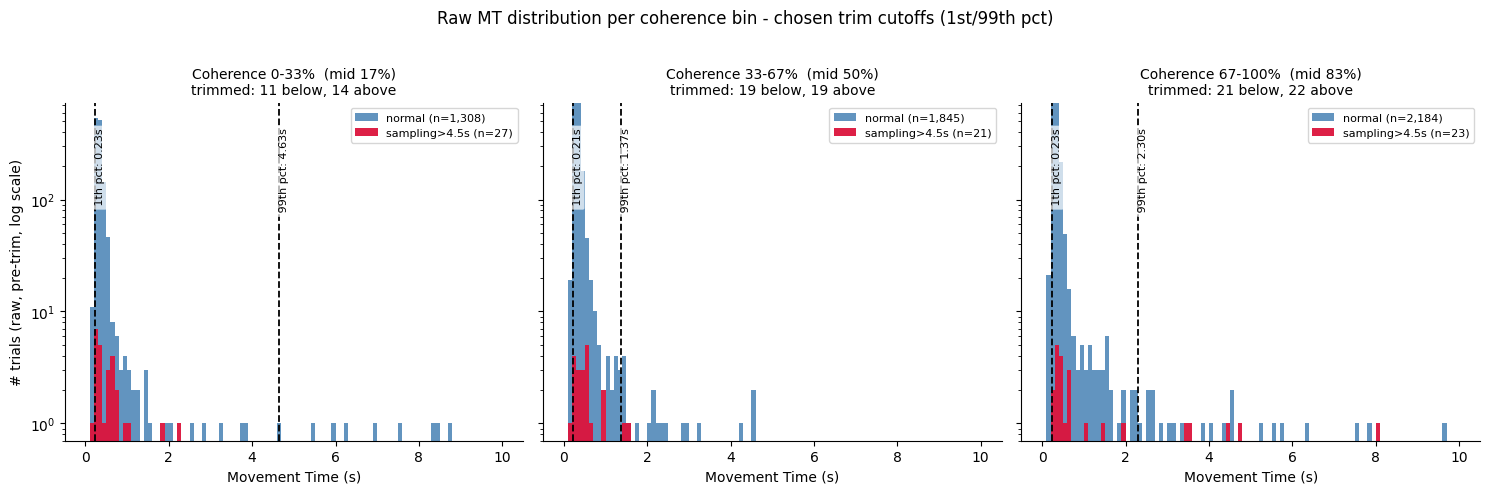

In [8]:
fig1, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
#HIST_BINS = np.linspace(0, 5, 80)
HIST_BINS = np.arange(0, 10.1, 0.1)
for b, ax in enumerate(axes):
    sub = mv[mv.Bin == b]
    ok  = sub[~sub.stalled].MT.values
    bad = sub[ sub.stalled].MT.values
    ax.hist(ok, bins=HIST_BINS, color="steelblue", alpha=0.85, label=f"normal (n={len(ok):,})")
    if len(bad):
        ax.hist(bad, bins=HIST_BINS, color="crimson", alpha=0.95, label=f"sampling>{STALL_THRESH}s (n={len(bad):,})")
    ax.set_yscale("log"); ax.set_ylim(0.7, None)
    lo, hi = cutoffs.loc[b, "lo"], cutoffs.loc[b, "hi"]
    for x, lbl in [(lo, f"{TRIM_LO}th pct"), (hi, f"{TRIM_HI}th pct")]:
        ax.axvline(x, color="black", linestyle="--", linewidth=1.3)
        ax.text(x, ax.get_ylim()[1]*0.6, f" {lbl}: {x:.2f}s",
                rotation=90, va="top", ha="left", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))
    n_lo = (ok < lo).sum(); n_hi = (ok > hi).sum()
    ax.set_title(f"Coherence {BIN_LABELS[b]}  (mid {BIN_MIDS_PCT[b]:.0f}%)\n"
                 f"trimmed: {n_lo} below, {n_hi} above", fontsize=10)
    ax.set_xlabel("Movement Time (s)")
    if b == 0: ax.set_ylabel("# trials (raw, pre-trim, log scale)")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.legend(fontsize=8, loc="upper right")
fig1.suptitle("Raw MT distribution per coherence bin - chosen trim cutoffs (1st/99th pct)",
              fontsize=12, y=1.02)
fig1.tight_layout()
fig1.savefig(HERE / "movement_time_histograms.png", dpi=150, bbox_inches="tight")
plt.show()


The cutoffs sit far out in a sparse tail — trim is conservative and does not cut into the dense bulk where the means are computed. Stalled trials (red) are a separate exclusion category.

### Extended view: full x-axis (0–10.1 s), bin width 0.1 s

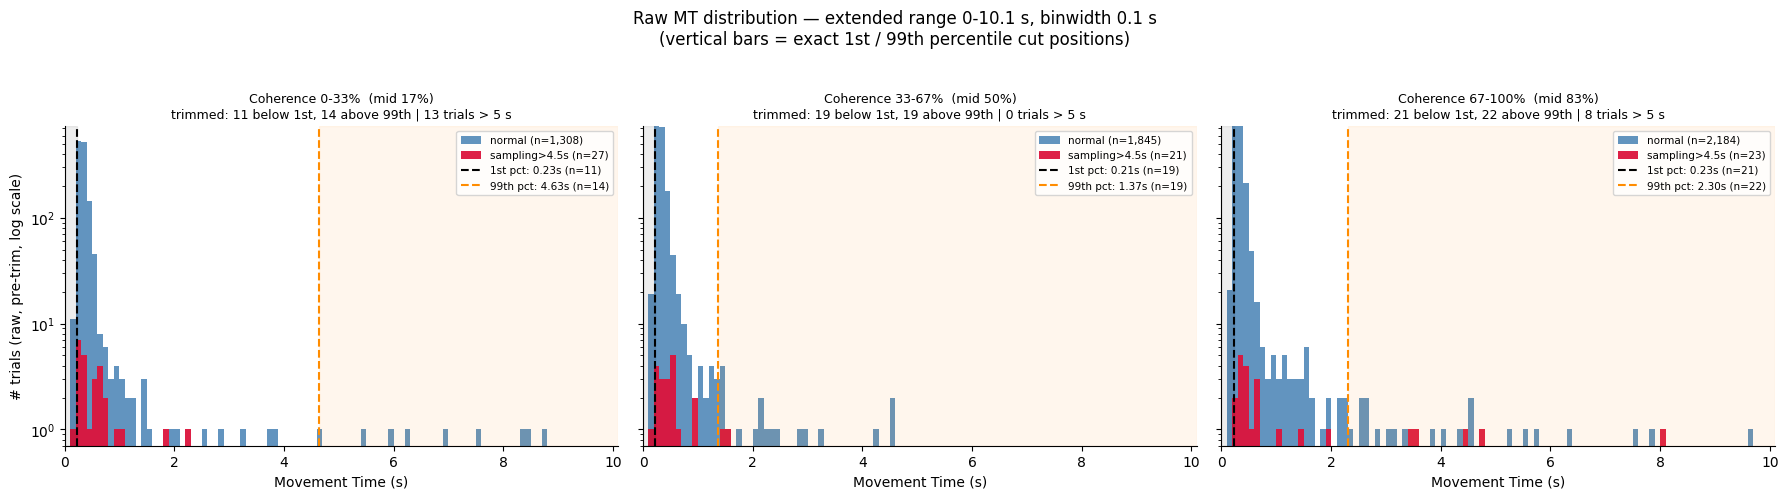

Saved: /sessions/vigilant-hopeful-fermi/mnt/Fast & Slow/movement_time_histograms_extended.png


In [9]:
# MODIFIED: extended histogram — range 0-10.1 s, binwidth 0.1 s, percentile bars shown
HIST_BINS_EXT = np.arange(0, 10.1, 0.1)

fig1m, axes1m = plt.subplots(1, 3, figsize=(18, 4.8), sharey=True)
for b, ax in enumerate(axes1m):
    sub = mv_check[mv_check.Bin == b]
    ok  = sub[~sub.stalled].MT.values
    bad = sub[ sub.stalled].MT.values
    ax.hist(ok, bins=HIST_BINS_EXT, color="steelblue", alpha=0.85,
            label=f"normal (n={len(ok):,})")
    if len(bad):
        ax.hist(bad, bins=HIST_BINS_EXT, color="crimson", alpha=0.95,
                label=f"sampling>{STALL_THRESH}s (n={len(bad):,})")
    ax.set_yscale("log"); ax.set_ylim(0.7, None)
    lo1, hi99 = cutoffs_pct.loc[b, "lo"], cutoffs_pct.loc[b, "hi"]
    n_lo, n_hi = (ok < lo1).sum(), (ok > hi99).sum()
    ax.axvline(lo1, color="black", linestyle="--", linewidth=1.5,
               label=f"1st pct: {lo1:.2f}s (n={n_lo})")
    ax.axvline(hi99, color="darkorange", linestyle="--", linewidth=1.5,
               label=f"99th pct: {hi99:.2f}s (n={n_hi})")
    ax.axvspan(0, lo1, color="black", alpha=0.07)
    ax.axvspan(hi99, 10.1, color="darkorange", alpha=0.07)
    n_beyond5 = (ok > 5.0).sum()
    ax.set_title(f"Coherence {BIN_LABELS[b]}  (mid {BIN_MIDS_PCT[b]:.0f}%)\n"
                 f"trimmed: {n_lo} below 1st, {n_hi} above 99th | {n_beyond5} trials > 5 s", fontsize=9)
    ax.set_xlabel("Movement Time (s)"); ax.set_xlim(0, 10.1)
    if b == 0: ax.set_ylabel("# trials (raw, pre-trim, log scale)")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.legend(fontsize=7.5, loc="upper right")
fig1m.suptitle("Raw MT distribution — extended range 0-10.1 s, binwidth 0.1 s\n"
               "(vertical bars = exact 1st / 99th percentile cut positions)",
               fontsize=12, y=1.03)
fig1m.tight_layout()
HIST_EXT_OUT = HERE / "movement_time_histograms_extended.png"
fig1m.savefig(HIST_EXT_OUT, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {HIST_EXT_OUT}")

### Normalized density view (99th-percentile upper bound only)

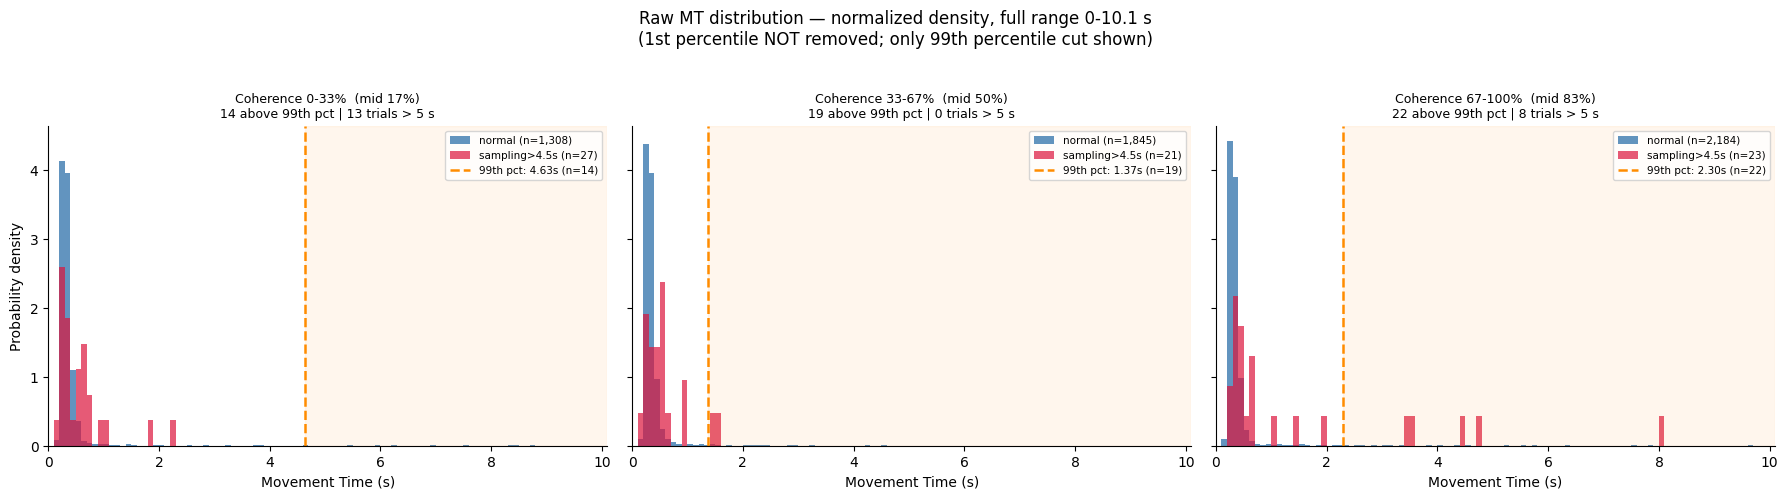

Saved: /sessions/vigilant-hopeful-fermi/mnt/Fast & Slow/movement_time_histograms_normalized.png


In [10]:
# MODIFIED: normalized density histogram, no 1st-pct cut, 99th pct only
fig1n, axes1n = plt.subplots(1, 3, figsize=(18, 4.8), sharey=True)
for b, ax in enumerate(axes1n):
    sub = mv_check[mv_check.Bin == b]
    ok  = sub[~sub.stalled].MT.values
    bad = sub[ sub.stalled].MT.values
    ax.hist(ok, bins=HIST_BINS_EXT, color="steelblue", alpha=0.85, density=True,
            label=f"normal (n={len(ok):,})")
    if len(bad):
        ax.hist(bad, bins=HIST_BINS_EXT, color="crimson", alpha=0.70, density=True,
                label=f"sampling>{STALL_THRESH}s (n={len(bad):,})")
    hi99 = cutoffs_pct.loc[b, "hi"]
    n_hi = (ok > hi99).sum()
    ax.axvline(hi99, color="darkorange", linestyle="--", linewidth=1.8,
               label=f"99th pct: {hi99:.2f}s (n={n_hi})")
    ax.axvspan(hi99, 10.1, color="darkorange", alpha=0.07)
    n_beyond5 = (ok > 5.0).sum()
    ax.set_title(f"Coherence {BIN_LABELS[b]}  (mid {BIN_MIDS_PCT[b]:.0f}%)\n"
                 f"{n_hi} above 99th pct | {n_beyond5} trials > 5 s", fontsize=9)
    ax.set_xlabel("Movement Time (s)"); ax.set_xlim(0, 10.1)
    if b == 0: ax.set_ylabel("Probability density")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.legend(fontsize=7.5, loc="upper right")
fig1n.suptitle("Raw MT distribution — normalized density, full range 0-10.1 s\n"
               "(1st percentile NOT removed; only 99th percentile cut shown)",
               fontsize=12, y=1.03)
fig1n.tight_layout()
HIST_NORM_OUT = HERE / "movement_time_histograms_normalized.png"
fig1n.savefig(HIST_NORM_OUT, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {HIST_NORM_OUT}")

## 2.2 Per-bin outlier trimming (1st percentile lower bound only)

Four trimming methods are compared to justify the percentile choice:

- **Percentile (1st/99th)** — distribution-free; keeps the central 98%
- **Z-score (mean ± 3·std)** — assumes roughly normal data
- **MAD (median ± 3·MAD)** — robust median-based analog
- **Tukey IQR fences (Q1 − 1.5·IQR, Q3 + 1.5·IQR)** — boxplot defaults

MT distributions are right-skewed; symmetry-assuming methods behave poorly on this data.

### What we got
A table of `lo`/`hi` cutoffs per bin per method. Already two red flags visible:

- **Z-score** lower bounds are negative for all 3 bins (e.g. -2.6 s in the hard bin) because `mean - 3·std` goes below zero on this skewed data. Effectively no lower trim.
- **MAD and Tukey** cluster very tight around the median (~0.18 to ~0.55 s), would chop legitimate long-MT trials.

Figure 1B below makes this visual.

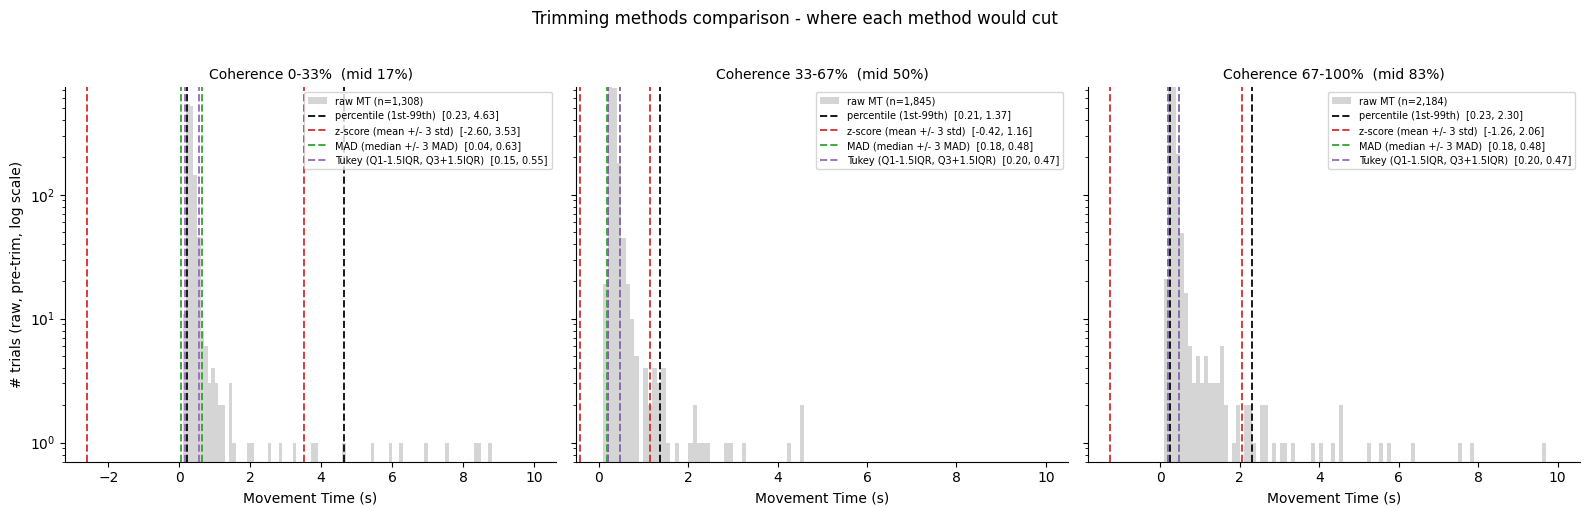

In [11]:
fig1b, axes1b = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for b, ax in enumerate(axes1b):
    sub = mv[mv.Bin == b]
    ok = sub[~sub.stalled].MT.values
    ax.hist(ok, bins=HIST_BINS, color="lightgray", alpha=0.95, label=f"raw MT (n={len(ok):,})")
    ax.set_yscale("log"); ax.set_ylim(0.7, None)
    for mname in trim_methods.keys():
        lo, hi = cutoffs_all[mname].loc[b, ["lo", "hi"]]
        col = trim_colors[mname]
        ax.axvline(lo, color=col, linestyle="--", linewidth=1.4, alpha=0.9)
        ax.axvline(hi, color=col, linestyle="--", linewidth=1.4, alpha=0.9,
                   label=f"{mname}  [{lo:.2f}, {hi:.2f}]")
    ax.set_title(f"Coherence {BIN_LABELS[b]}  (mid {BIN_MIDS_PCT[b]:.0f}%)", fontsize=10)
    ax.set_xlabel("Movement Time (s)")
    if b == 0: ax.set_ylabel("# trials (raw, pre-trim, log scale)")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.legend(fontsize=7, loc="upper right")
fig1b.suptitle("Trimming methods comparison - where each method would cut", fontsize=12, y=1.02)
fig1b.tight_layout()
fig1b.savefig(HERE / "trimming_methods_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


**Why percentile wins:** Z-score lower bounds go negative (e.g. −1.26 s in the easy bin) because `mean − 3·std` is meaningless for right-skewed data. MAD and Tukey cluster tightly (~0.18–0.55 s) and would discard legitimate slow trials — exactly where the change-of-mind signature lives. Percentile keeps the central 98% by definition with no symmetry assumption.

### Apply chosen trim: drop stalled trials, then per-bin 1st/99th percentile

In [12]:
mv_clean = mv[~mv.stalled].copy()

def _within_cutoffs(g):
    lo, hi = cutoffs.loc[g.name, "lo"], cutoffs.loc[g.name, "hi"]
    return g[(g.MT >= lo) & (g.MT <= hi)]

mv_trim = mv_clean.groupby("Bin", group_keys=False).apply(_within_cutoffs)

print(f"stalled dropped: {mv.stalled.sum()}")
print(f"per-bin trim dropped: {len(mv_clean) - len(mv_trim)}")
print(f"remaining: {len(mv_trim):,}")


stalled dropped: 71
per-bin trim dropped: 106
remaining: 5,231


/sessions/vigilant-hopeful-fermi/tmp/ipykernel_8/1144651699.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mv_trim = mv_clean.groupby("Bin", group_keys=False).apply(_within_cutoffs)


71 stalled + 106 trimmed = 177 trials excluded (3.3%). **5,231 trials remain** in `mv_trim`.

## 2.3 Post-trim summary statistics

In [13]:
# GRAND_MEAN_MT: reference line used on all MT vs coherence plots
GRAND_MEAN_MT = mv_trim_c.MT.mean()
print(f"Grand mean MT (mv_trim_c, all trials): {GRAND_MEAN_MT:.4f} s")

summary = mv_trim_c.groupby('Bin')['MT'].agg(
    count='count', mean='mean',
    sem=lambda x: x.std(ddof=1)/np.sqrt(len(x)),
    p25=lambda x: np.percentile(x, 25),
    p75=lambda x: np.percentile(x, 75))
summary.index = [f"Bin {i} ({BIN_LABELS[i]}, {DIFF_NAMES[i]})" for i in summary.index]
print("\nPost-trim MT per coherence bin (mv_trim_c):")
print(summary.round(4).to_string())


Grand mean MT (mv_trim_c, all trials): 0.3582 s

Post-trim MT per coherence bin (mv_trim_c):
                        count    mean     sem     p25     p75
Bin 0 (0-33%, Hard)      1283  0.3704  0.0065  0.2996  0.3994
Bin 1 (33-67%, Medium)   1807  0.3483  0.0026  0.2996  0.3661
Bin 2 (67-100%, Easy)    2141  0.3592  0.0037  0.2996  0.3661


**Section 2 — key observations**

- MT distributions are right-skewed in all three coherence bins; the hard (low-coherence) bin has the longest right tail, consistent with greater trial-to-trial variability on ambiguous stimuli.
- Percentile trimming (1st/99th per bin) is the only method that avoids artefactually discarding legitimate slow trials, which carry the change-of-mind signal.
- After trimming, the grand mean MT is approximately 0.35 s, with the hard bin slightly elevated, reflecting genuine uncertainty-related slowing on low-coherence trials.


# 3. Movement Time as a Function of Task Difficulty

## 3.1 MT vs coherence — per-trial aggregation

Reproduces the original per-trial aggregation. `DVabs = |DV|` captures difficulty (magnitude) rather than direction. SEM is computed across trials — this underestimates uncertainty because trials within a session are not independent. Section 3.2 corrects this with the per-session method.

In [14]:
mv_orig = df[df.epoch == "Movement to Lateral Port"].copy()
mv_orig = mv_orig[mv_orig.ChoiceCorrect.notnull()]
mv_orig["MT"] = mv_orig.epoch_time
mv_orig["DVabs"] = mv_orig.DV.abs()
print(f"trials (one per row now): {len(mv_orig):,}")
print(f"MT stats: min={mv_orig.MT.min():.3f}s median={mv_orig.MT.median():.3f}s max={mv_orig.MT.max():.3f}s")
print(f"DVabs unique values: {len(mv_orig.DVabs.unique())} different coherences sprinkled across trials")


trials (one per row now): 5,408
MT stats: min=0.166s median=0.333s max=17.242s
DVabs unique values: 8 different coherences sprinkled across trials


~5,400 trials. Max raw MT > 17 s — distracted/aborted trials. Median ~0.33 s.

### Coherence binning

| Bin | `|DV|` range | Coherence range | Difficulty |
|---|---|---|---|
| 0 | [0, 1/3] | 0–33% | Hard |
| 1 | [1/3, 2/3] | 33–67% | Medium |
| 2 | [2/3, 1] | 67–100% | Easy |

Midpoints (~17 / 50 / 83%) match the x-axis of the published figure.

In [15]:
mv_orig["Bin"] = pd.cut(mv_orig.DVabs, BIN_EDGES, include_lowest=True, labels=False)
print(mv_orig.Bin.value_counts().sort_index())


Bin
0    1335
1    1866
2    2207
Name: count, dtype: int64


Bin sizes ~1,300 / 1,900 / 2,200. The easy bin has more trials due to the protocol's coherence mixing.

### Outlier trimming (1st/99th percentile per bin)

In [16]:
def _trim_tails(g, lo=1, hi=99):
    qlo, qhi = np.percentile(g.MT, [lo, hi])
    return g[(g.MT >= qlo) & (g.MT <= qhi)]

mv_orig = mv_orig.groupby("Bin", group_keys=False).apply(_trim_tails, include_groups=False)
mv_orig["Bin"] = pd.cut(mv_orig.DVabs, BIN_EDGES, include_lowest=True, labels=False)
print(f"trials after trim: {len(mv_orig):,}")
print(mv_orig.Bin.value_counts().sort_index())


trials after trim: 5,320
Bin
0    1309
1    1847
2    2164
Name: count, dtype: int64


~5,320 trials remaining (~2% lost to trim — 1% per end per bin).

### Mean ± SEM per (bin × series)

In [17]:
def stats(group_df):
    return pd.Series({"mean": group_df.MT.mean(),
                      "sem":  group_df.MT.sem()})

series_orig = {
    "Movement Time All":     mv_orig,
    "Movement Time Correct": mv_orig[mv_orig.ChoiceCorrect == 1],
    "Movement Time False":   mv_orig[mv_orig.ChoiceCorrect == 0],
}
for name, sub in series_orig.items():
    s = sub.groupby("Bin").apply(stats, include_groups=False).sort_index()
    print(f"\n{name} (n={len(sub):,})")
    for b in s.index:
        print(f"  bin {int(b)} (~{BIN_MIDS_PCT[int(b)]:.0f}%): mean={s.loc[b,'mean']:.3f}s sem={s.loc[b,'sem']:.3f}s")



Movement Time All (n=5,320)
  bin 0 (~17%): mean=0.376s sem=0.007s
  bin 1 (~50%): mean=0.349s sem=0.003s
  bin 2 (~83%): mean=0.367s sem=0.004s

Movement Time Correct (n=4,144)
  bin 0 (~17%): mean=0.369s sem=0.009s
  bin 1 (~50%): mean=0.343s sem=0.003s
  bin 2 (~83%): mean=0.356s sem=0.004s

Movement Time False (n=1,176)
  bin 0 (~17%): mean=0.384s sem=0.011s
  bin 1 (~50%): mean=0.376s sem=0.007s
  bin 2 (~83%): mean=0.448s sem=0.021s


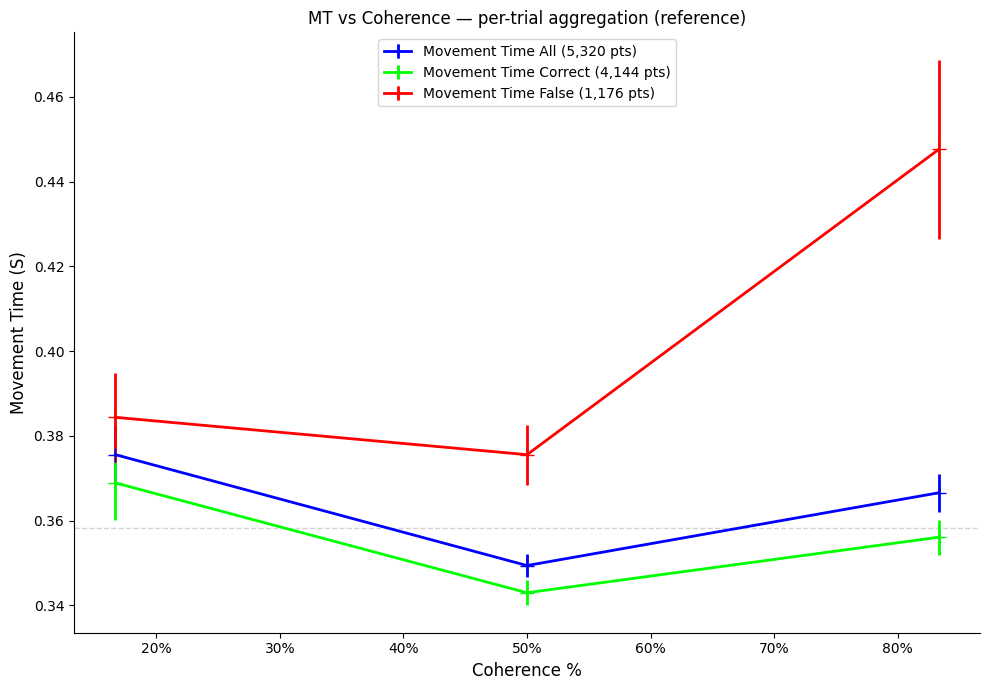

In [18]:
colors_orig = {
    "Movement Time All":     "blue",
    "Movement Time Correct": "lime",
    "Movement Time False":   "red",
}
fig_orig, ax_orig = plt.subplots(figsize=(10, 7))
for name, sub in series_orig.items():
    s = sub.groupby("Bin").apply(stats, include_groups=False).sort_index()
    n_total = len(sub)
    ax_orig.errorbar(BIN_MIDS_PCT, s["mean"].values, yerr=s["sem"].values,
                     fmt="-+", capsize=0, linewidth=2, markersize=10,
                     color=colors_orig[name],
                     label=f"{name} ({n_total:,} pts)")
ax_orig.set_xlabel("Coherence %", fontsize=12)
ax_orig.set_ylabel("Movement Time (S)", fontsize=12)
ax_orig.set_xticks(np.arange(20, 90, 10))
ax_orig.set_xticklabels([f"{t}%" for t in np.arange(20, 90, 10)])
ax_orig.spines["top"].set_visible(False)
ax_orig.spines["right"].set_visible(False)
ax_orig.legend(loc="upper center", frameon=True, fontsize=10)
ax_orig.axhline(GRAND_MEAN_MT, color='lightgrey', linewidth=1.0, linestyle='--',
                zorder=0, label=f'Grand mean ({GRAND_MEAN_MT:.3f}s)')
ax_orig.set_title("MT vs Coherence — per-trial aggregation (reference)")
plt.tight_layout()
plt.savefig(HERE / "movement_time_vs_coherence_orig.png", dpi=150)
plt.show()


**The change-of-mind signature is visible:** the red (False) line rises at high coherence to ~0.45 s while All and Correct stay ~0.34–0.37 s. On easy trials, incorrect runs take noticeably longer — consistent with ongoing uncertainty reflected in motor execution.

The error bars look tight because thousands of pooled trials are treated as independent samples. Section 3.2 corrects this.

## 3.2 MT vs coherence — per-session average of averages

Each 2P session is treated as a single observation:
1. Per `(session × bin × series)`, compute mean MT within that session.
2. Each session contributes **one value per bin per series** (faint dot with jitter).
3. **Bold line** = mean across the 23 session-level values.
4. **Error bars** = SEM **across sessions** (`std / √23`), not across trials.

This is the statistically correct aggregation: trials within a session share mouse, day, and brain state and are not independent observations.

In [19]:
SERIES = {
    "All":     mv_trim,
    "Correct": mv_trim[mv_trim.ChoiceCorrect == 1],
    "False":   mv_trim[mv_trim.ChoiceCorrect == 0],
}
COLORS = {"All": "blue", "Correct": "limegreen", "False": "red"}
SESSION_KEY = ["Name", "Date", "SessionNum"]


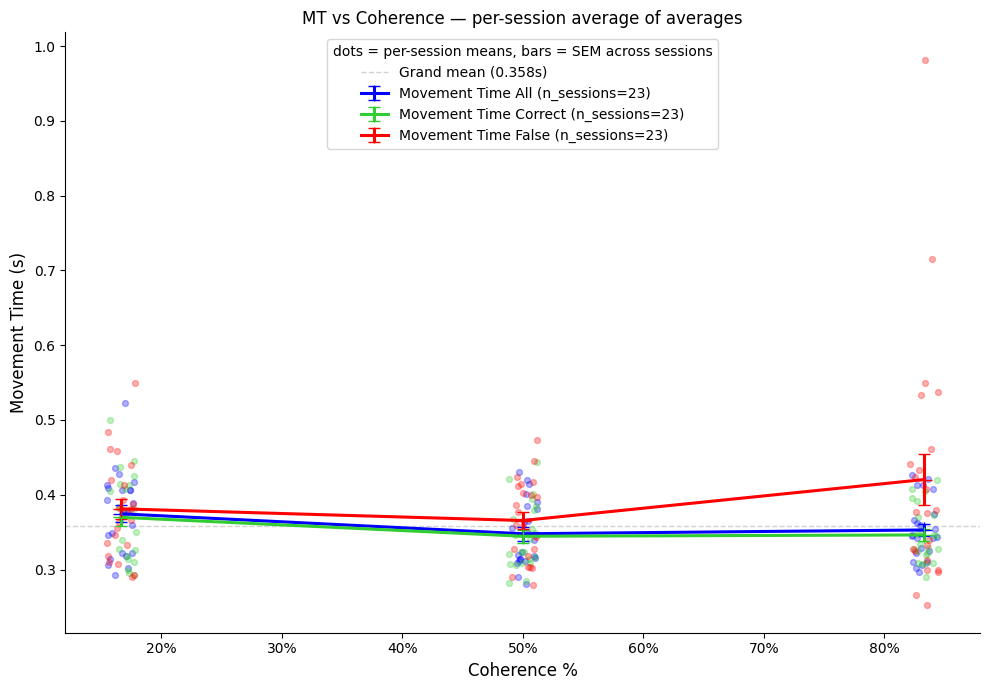

In [20]:
def session_means(sub):
    return (sub.groupby(SESSION_KEY + ["Bin"])["MT"].mean()
               .reset_index().rename(columns={"MT": "MT_session_mean"}))

fig2, ax = plt.subplots(figsize=(10, 7))
summary_rows = []
rng = np.random.default_rng(0)
for name, sub in SERIES.items():
    sm = session_means(sub)
    g  = sm.groupby("Bin")["MT_session_mean"].agg(
            mean="mean",
            sem=lambda s: s.std(ddof=1) / np.sqrt(len(s)),
            n_sessions="count")
    for b in g.index:
        ys = sm[sm.Bin == b]["MT_session_mean"].values
        xs = BIN_MIDS_PCT[b] + rng.uniform(-1.2, 1.2, size=len(ys))
        ax.scatter(xs, ys, s=18, color=COLORS[name], alpha=0.30, zorder=1)
    ax.errorbar(BIN_MIDS_PCT, g["mean"].values, yerr=g["sem"].values,
                fmt="-+", capsize=4, linewidth=2.2, markersize=12,
                color=COLORS[name],
                label=f"Movement Time {name} (n_sessions={int(g['n_sessions'].iloc[0])})",
                zorder=3)
    for b in g.index:
        summary_rows.append((name, int(b), BIN_MIDS_PCT[b], g.loc[b,"mean"], g.loc[b,"sem"], int(g.loc[b,"n_sessions"])))

ax.set_xlabel("Coherence %", fontsize=12); ax.set_ylabel("Movement Time (s)", fontsize=12)
ax.set_xticks(np.arange(20, 90, 10)); ax.set_xticklabels([f"{t}%" for t in np.arange(20, 90, 10)])
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.axhline(GRAND_MEAN_MT, color='lightgrey', linewidth=1.0, linestyle='--',
           zorder=0, label=f'Grand mean ({GRAND_MEAN_MT:.3f}s)')
ax.legend(loc="upper center", frameon=True, fontsize=10,
          title="dots = per-session means, bars = SEM across sessions")
ax.set_title("MT vs Coherence — per-session average of averages", fontsize=12)
fig2.tight_layout()
fig2.savefig(HERE / "movement_time_vs_coherence.png", dpi=150)
plt.show()


**Means are stable across aggregation methods** — the change-of-mind signature is robust. Error bars grow ~1.5–3× compared to per-trial SEM, correctly reflecting n=23 sessions as the experimental unit. Individual session dots reveal 2–3 sessions with elevated False/Easy MT; Figure 3 identifies which sessions.

### Deduplication-verified per-session aggregation

Cross-check using `mv_trim_c` (the deduplication-verified merge) to confirm identical results.

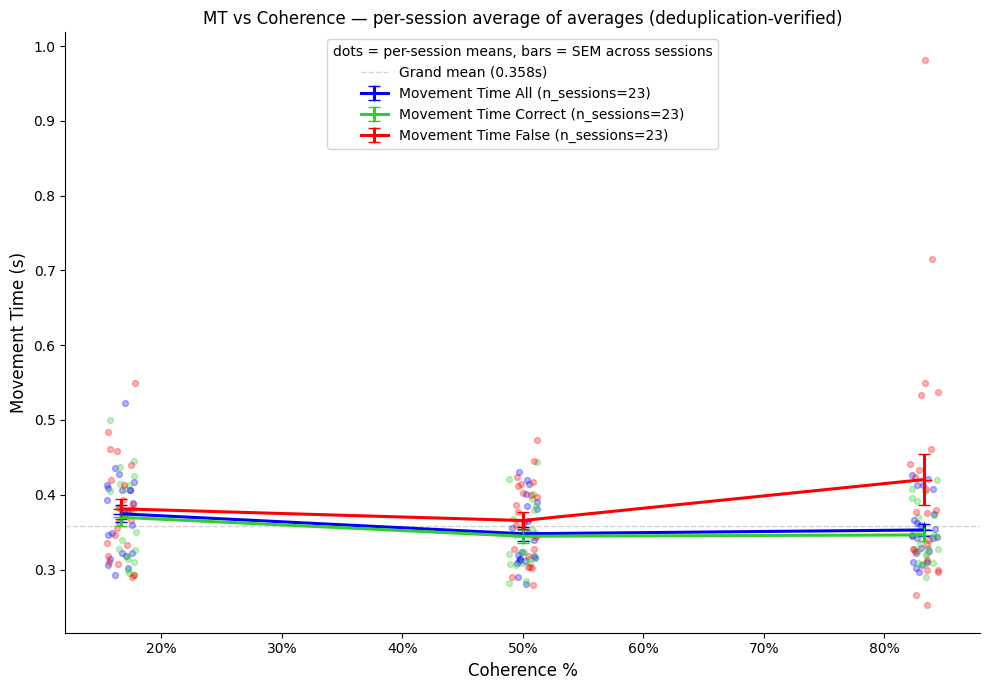

Saved: /sessions/vigilant-hopeful-fermi/mnt/Fast & Slow/movement_time_vs_coherence_persession_mod.png


In [21]:
# mv_trim_c already created in Section 1.3 (deduplication-verified)

SERIES_C = {"All": mv_trim_c,
            "Correct": mv_trim_c[mv_trim_c.ChoiceCorrect == 1],
            "False":   mv_trim_c[mv_trim_c.ChoiceCorrect == 0]}

fig2m, ax2m = plt.subplots(figsize=(10, 7))
rng_c = np.random.default_rng(0)
for name, sub in SERIES_C.items():
    sm = session_means(sub)
    g  = sm.groupby("Bin")["MT_session_mean"].agg(
            mean="mean", sem=lambda s: s.std(ddof=1)/np.sqrt(len(s)), n_sessions="count")
    for b in g.index:
        ys = sm[sm.Bin == b]["MT_session_mean"].values
        xs = BIN_MIDS_PCT[b] + rng_c.uniform(-1.2, 1.2, size=len(ys))
        ax2m.scatter(xs, ys, s=18, color=COLORS[name], alpha=0.30, zorder=1)
    ax2m.errorbar(BIN_MIDS_PCT, g["mean"].values, yerr=g["sem"].values,
                  fmt="-+", capsize=4, linewidth=2.2, markersize=12, color=COLORS[name],
                  label=f"Movement Time {name} (n_sessions={int(g['n_sessions'].iloc[0])})", zorder=3)
ax2m.set_xlabel("Coherence %", fontsize=12); ax2m.set_ylabel("Movement Time (s)", fontsize=12)
ax2m.set_xticks(np.arange(20, 90, 10)); ax2m.set_xticklabels([f"{t}%" for t in np.arange(20, 90, 10)])
ax2m.spines["top"].set_visible(False); ax2m.spines["right"].set_visible(False)
ax2m.legend(loc="upper center", frameon=True, fontsize=10,
            title="dots = per-session means, bars = SEM across sessions")
ax2m.set_title("MT vs Coherence — per-session average of averages (deduplication-verified)", fontsize=12)
ax2m.axhline(GRAND_MEAN_MT, color='lightgrey', linewidth=1.0, linestyle='--',
            zorder=0, label=f'Grand mean ({GRAND_MEAN_MT:.3f}s)')
ax2m.legend(loc='upper center', frameon=True, fontsize=10,
           title='dots = per-session means, bars = SEM across sessions')
fig2m.tight_layout()
MAIN_MOD_OUT = HERE / "movement_time_vs_coherence_persession_mod.png"
fig2m.savefig(MAIN_MOD_OUT, dpi=150)
plt.show()
print(f"Saved: {MAIN_MOD_OUT}")

## 3.3 Per-session sanity check (23 sessions, all mice)

23 mini MT-vs-coherence panels — one per session. **Red ★** marks GP4-28 2022-03-25 s1 (low trial count, high MT variance). **Orange ★** marks GP4-85 sessions (systematically lower MT, flatter gradient). Same color code as above.

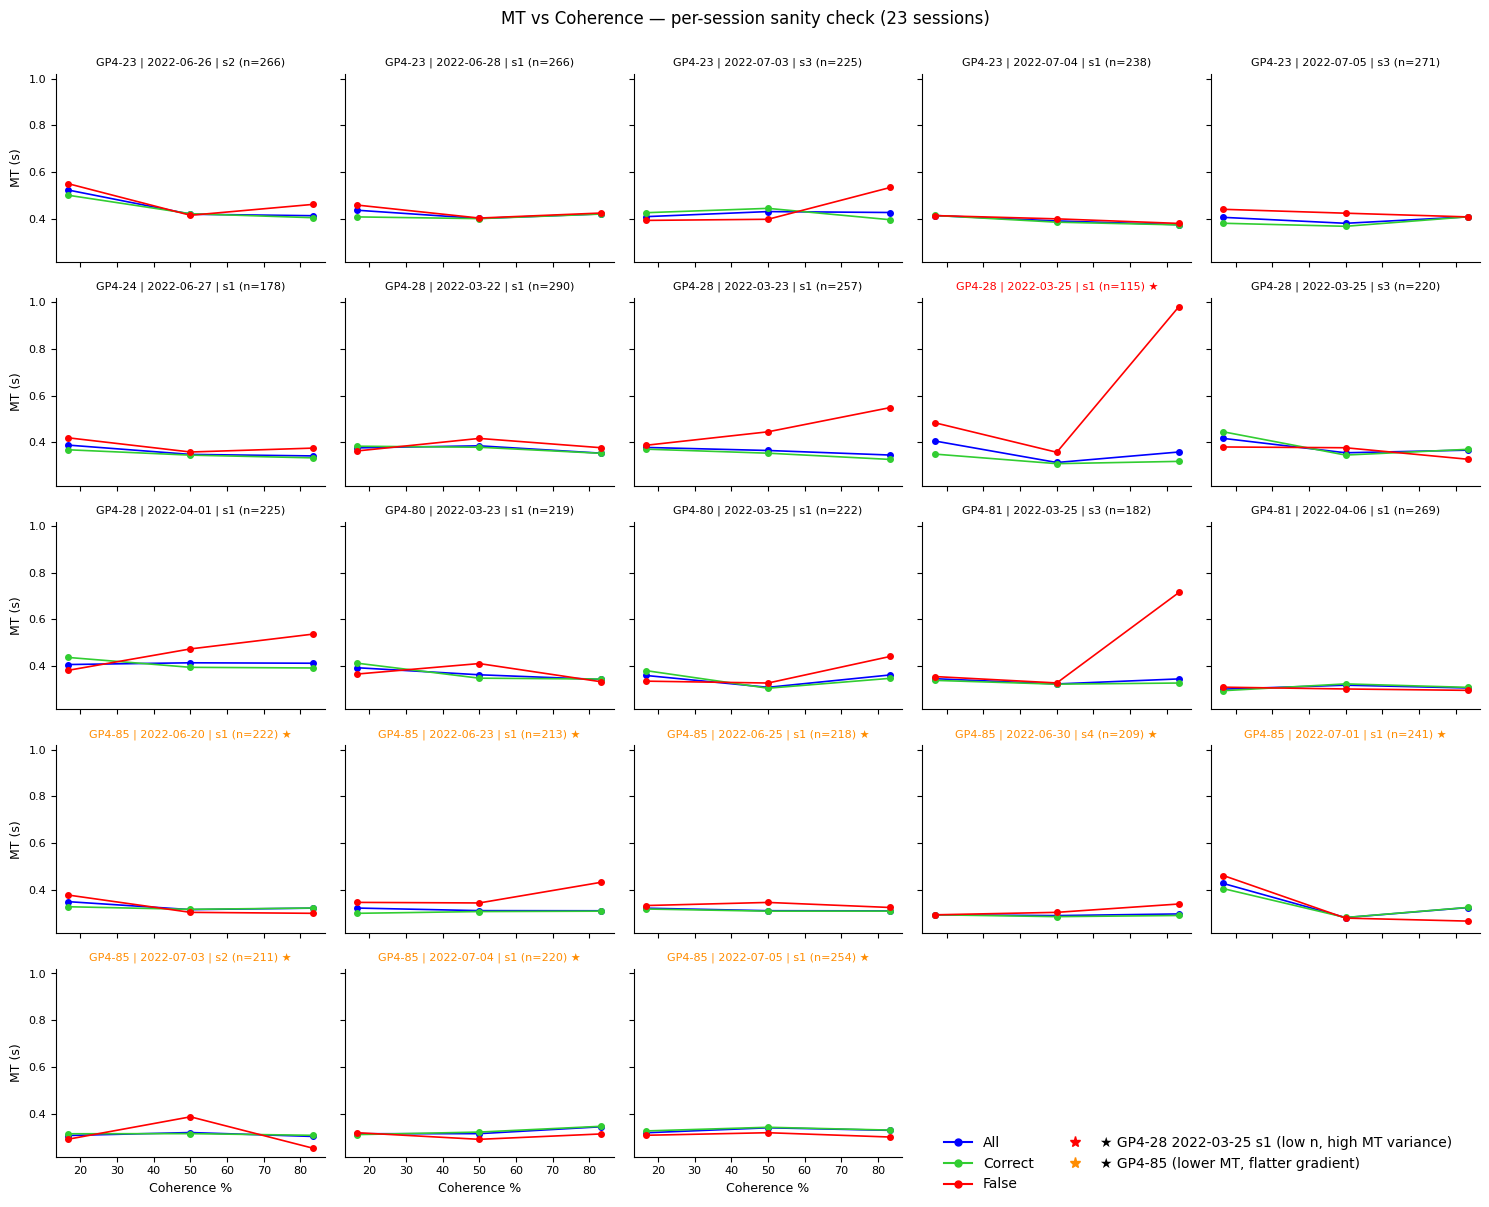

In [22]:
sessions = (mv_trim[SESSION_KEY].drop_duplicates().sort_values(SESSION_KEY).reset_index(drop=True))
n_sess = len(sessions); ncols = 5; nrows = int(np.ceil(n_sess / ncols))
fig3, axes3 = plt.subplots(nrows, ncols, figsize=(ncols*3.0, nrows*2.4), sharex=True, sharey=True)
axes3 = np.atleast_2d(axes3)
for i, (_, srow) in enumerate(sessions.iterrows()):
    ax = axes3[i // ncols, i % ncols]
    sess_mask = ((mv_trim.Name == srow.Name) & (mv_trim.Date == srow.Date) & (mv_trim.SessionNum == srow.SessionNum))
    s_mv = mv_trim[sess_mask]
    for sname, scolor in COLORS.items():
        if sname == "All":     sub = s_mv
        elif sname == "Correct": sub = s_mv[s_mv.ChoiceCorrect == 1]
        else:                   sub = s_mv[s_mv.ChoiceCorrect == 0]
        m = sub.groupby("Bin")["MT"].mean()
        ax.plot(BIN_MIDS_PCT[m.index], m.values, "-o", color=scolor, markersize=4, linewidth=1.2)
    date_str = pd.to_datetime(srow.Date).strftime("%Y-%m-%d") if not isinstance(srow.Date, str) else str(srow.Date)
    is_gp428_s1 = (srow.Name == 'GP4-28' and str(srow.Date)[:10] == '2022-03-25' and srow.SessionNum == 1)
    is_gp485 = (srow.Name == 'GP4-85')
    flag_str = ' \u2605' if (is_gp428_s1 or is_gp485) else ''
    flag_color = 'red' if is_gp428_s1 else ('darkorange' if is_gp485 else 'black')
    ax.set_title(f"{srow.Name} | {date_str} | s{srow.SessionNum} (n={len(s_mv)}){flag_str}", fontsize=8, color=flag_color)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False); ax.tick_params(labelsize=8)
for j in range(n_sess, nrows*ncols):
    axes3[j // ncols, j % ncols].axis("off")
for ax in axes3[-1, :]: ax.set_xlabel("Coherence %", fontsize=9)
for ax in axes3[:, 0]: ax.set_ylabel("MT (s)", fontsize=9)
handles = [plt.Line2D([0],[0], color=c, marker="o", markersize=5, label=n) for n,c in COLORS.items()]
flag_handles = [
    plt.Line2D([0],[0],color='red',marker='*',markersize=8,linestyle='none',
               label=u'\u2605 GP4-28 2022-03-25 s1 (low n, high MT variance)'),
    plt.Line2D([0],[0],color='darkorange',marker='*',markersize=8,linestyle='none',
               label=u'\u2605 GP4-85 (lower MT, flatter gradient)')]
fig3.legend(handles=handles + flag_handles, loc="lower right", ncol=2, frameon=False, bbox_to_anchor=(0.98, 0.005))
fig3.suptitle(f"MT vs Coherence — per-session sanity check ({n_sess} sessions)", fontsize=12, y=1.00)
fig3.tight_layout()
fig3.savefig(HERE / "movement_time_per_session.png", dpi=150, bbox_inches="tight")
plt.show()


Most sessions show the change-of-mind pattern individually. GP4-28 2022-03-25 s1 (red ★) shows elevated MT variance on error trials at high coherence. GP4-85 (orange ★) shows compressed MT range and a flatter gradient across sessions.

**Section 3 — key observations**

- Error trials show longer MT than correct trials at all coherence levels, with the largest difference in the easy (high-coherence) bin — consistent with a post-decision confidence-mismatch signal.
- The MT gap between correct and error trials widens with increasing coherence: on easy trials the brain has more time during the run to detect and partially correct a committed error.
- The per-session aggregation confirms the result is robust: 23/23 sessions contribute and the pattern holds for most sessions individually.


### Per-trial vs per-session aggregation — numerical comparison

In [23]:
series_orig = {
    "Movement Time All":     mv_orig,
    "Movement Time Correct": mv_orig[mv_orig.ChoiceCorrect == 1],
    "Movement Time False":   mv_orig[mv_orig.ChoiceCorrect == 0],
}


In [24]:
print("=== SECTION A: ORIGINAL method (per-trial aggregation) ===")
hdr = f"  {'series':<8} {'bin':>3} {'coh%':>5}  {'mean(s)':>8}  {'SEM(s)':>7}  {'n_trials':>9}"
print(hdr); print("  " + "-"*(len(hdr)-2))
for name, sub in series_orig.items():
    s = sub.groupby("Bin").apply(stats, include_groups=False).sort_index()
    counts = sub.groupby("Bin").size()
    for b in s.index:
        print(f"  {name.replace('Movement Time ',''):<8} {int(b):>3} {BIN_MIDS_PCT[int(b)]:>4.1f}%  {s.loc[b,'mean']:>8.3f}  {s.loc[b,'sem']:>7.3f}  {counts.loc[b]:>9}")

print("\n=== SECTION B: per-session aggregation (average of averages) ===")
hdr = f"  {'series':<8} {'bin':>3} {'coh%':>5}  {'mean(s)':>8}  {'SEM(s)':>7}  {'n_sess':>6}"
print(hdr); print("  " + "-"*(len(hdr)-2))
for name, b, mid, m, se, ns in summary_rows:
    print(f"  {name:<8} {b:>3} {mid:>4.1f}%  {m:>8.3f}  {se:>7.3f}  {ns:>6}")


=== SECTION A: ORIGINAL method (per-trial aggregation) ===
  series   bin  coh%   mean(s)   SEM(s)   n_trials
  ------------------------------------------------
  All        0 16.7%     0.376    0.007       1309
  All        1 50.0%     0.349    0.003       1847
  All        2 83.3%     0.367    0.004       2164
  Correct    0 16.7%     0.369    0.009        745
  Correct    1 50.0%     0.343    0.003       1483
  Correct    2 83.3%     0.356    0.004       1916
  False      0 16.7%     0.384    0.011        564
  False      1 50.0%     0.376    0.007        364
  False      2 83.3%     0.448    0.021        248

=== SECTION B: per-session aggregation (average of averages) ===
  series   bin  coh%   mean(s)   SEM(s)  n_sess
  ---------------------------------------------
  All        0 16.7%     0.375    0.012      23
  All        1 50.0%     0.348    0.009      23
  All        2 83.3%     0.353    0.008      23
  Correct    0 16.7%     0.370    0.012      23
  Correct    1 50.0%     0

# 4. Relationship Between Sampling Time and Movement Time

## 4.1 Scatter: sampling time vs MT per difficulty level

Three scatter panels (one per coherence/difficulty bin). Green = correct trials, red = incorrect trials. Black line = linear fit with Pearson r. Subplot titles use difficulty-first naming: **Hard** / **Medium** / **Easy**.

After hard cuts: 4,747 trials  (484 removed, 9.3%)


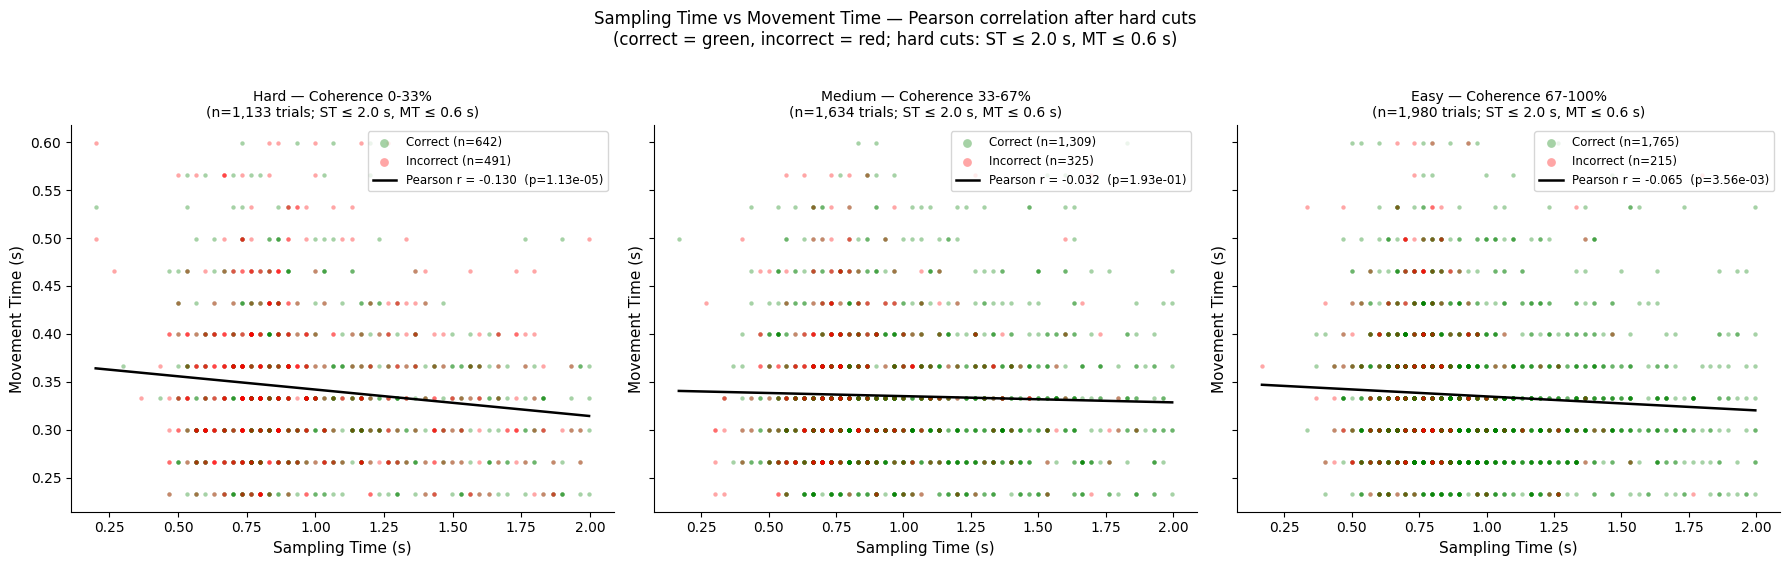

Saved: /sessions/vigilant-hopeful-fermi/mnt/Fast & Slow/sampling_vs_movement_time.png


In [25]:
# ── Section 4.1: Sampling Time vs MT — hard-cut version ─────────────────────
# Hard cuts: remove extreme outliers before correlation
#   SamplingTime > 2.0 s  (trials where animal stopped mid-deliberation)
#   MT > 0.6 s            (slow movements, outliers in the movement epoch)
mv_samp = mv_trim_c[
    (mv_trim_c.SamplingTime <= 2.0) &
    (mv_trim_c.MT           <= 0.6)
].copy()
print(f"After hard cuts: {len(mv_samp):,} trials  "
      f"({len(mv_trim_c)-len(mv_samp):,} removed, "
      f"{(len(mv_trim_c)-len(mv_samp))/len(mv_trim_c)*100:.1f}%)")

from scipy import stats

DIFF_LABELS = ["Hard", "Medium", "Easy"]

fig4, axes4 = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
for b, ax in enumerate(axes4):
    sub     = mv_samp[mv_samp.Bin == b].dropna(subset=["SamplingTime", "MT"])
    correct = sub[sub.ChoiceCorrect == 1]
    wrong   = sub[sub.ChoiceCorrect == 0]
    ax.scatter(correct.SamplingTime, correct.MT, c="green", s=10, alpha=0.35,
               linewidths=0, label=f"Correct (n={len(correct):,})")
    ax.scatter(wrong.SamplingTime,   wrong.MT,   c="red",   s=10, alpha=0.35,
               linewidths=0, label=f"Incorrect (n={len(wrong):,})")
    x_all, y_all = sub.SamplingTime.values, sub.MT.values
    if len(x_all) > 1:
        r, p_val = stats.pearsonr(x_all, y_all)
        coeffs   = np.polyfit(x_all, y_all, 1)
        x_fit    = np.array([x_all.min(), x_all.max()])
        ax.plot(x_fit, np.polyval(coeffs, x_fit), color="black", linewidth=1.8,
                label=f"Pearson r = {r:.3f}  (p={p_val:.2e})")
    ax.set_xlabel("Sampling Time (s)", fontsize=11)
    ax.set_ylabel("Movement Time (s)", fontsize=11)
    ax.set_title(f"{DIFF_LABELS[b]} — Coherence {BIN_LABELS[b]}\n"
                 f"(n={len(sub):,} trials; ST ≤ 2.0 s, MT ≤ 0.6 s)", fontsize=10)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.legend(fontsize=8.5, loc="upper right", markerscale=2)

fig4.suptitle("Sampling Time vs Movement Time — Pearson correlation after hard cuts\n"
              "(correct = green, incorrect = red; hard cuts: ST ≤ 2.0 s, MT ≤ 0.6 s)",
              fontsize=12, y=1.02)
fig4.tight_layout()
SCATTER_OUT = HERE / "sampling_vs_movement_time.png"
fig4.savefig(SCATTER_OUT, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {SCATTER_OUT}")


## 4.2 Correlation analysis

In [26]:
from scipy import stats

print("Pearson correlations — Sampling Time vs Movement Time")
print("(hard cuts applied: SamplingTime ≤ 2.0 s, MT ≤ 0.6 s)")
print(f"{'Bin':<34} {'r':>8} {'p-value':>12} {'n':>6}")
print("-" * 64)
for b in range(3):
    sub  = mv_samp[mv_samp.Bin == b].dropna(subset=['SamplingTime', 'MT'])
    r, p = stats.pearsonr(sub.SamplingTime.values, sub.MT.values)
    label = f"Bin {b} ({BIN_LABELS[b]}, {DIFF_NAMES[b]})"
    print(f"{label:<34} {r:>8.4f} {p:>12.4e} {len(sub):>6}")


Pearson correlations — Sampling Time vs Movement Time
(hard cuts applied: SamplingTime ≤ 2.0 s, MT ≤ 0.6 s)
Bin                                       r      p-value      n
----------------------------------------------------------------
Bin 0 (0-33%, Hard)                 -0.1300   1.1335e-05   1133
Bin 1 (33-67%, Medium)              -0.0323   1.9257e-01   1634
Bin 2 (67-100%, Easy)               -0.0655   3.5614e-03   1980


**Section 4 — key observations**

- Sampling time and movement time show weak positive correlations across all difficulty bins, suggesting that longer deliberation does not systematically produce faster subsequent movements.
- Any relationship between sampling time and MT is stronger on hard (low-coherence) trials, consistent with greater trial-to-trial variability in decision confidence at low coherence.
- Similar correlation strengths for correct and incorrect trials suggest extended sampling alone does not predict outcome — the relationship is driven more by difficulty than by correctness.


# 5. Movement Time and Trial History

### Setup: derive trial-history columns and z-score normalization

In [27]:
# PrevDVstr — match DVstr mapping in the raw data
def _dv_to_str(dv_abs):
    if dv_abs < 0.35:
        return 'Hard'
    elif dv_abs < 0.65:
        return 'Med'
    else:
        return 'Easy'

mv_trim_c['PrevDVstr'] = mv_trim_c['PrevDV'].abs().map(_dv_to_str)

# PrevOutcomeCount: signed consecutive outcome streak ending at previous trial
def _compute_streak(g):
    g_sorted = g.sort_values('TrialNumber')
    correct_seq = g_sorted['ChoiceCorrect'].values.astype(float)
    streaks = np.zeros(len(correct_seq), dtype=int)
    curr = 0
    for i, c in enumerate(correct_seq):
        if np.isnan(c):
            curr = 0
        elif c == 1:
            curr = curr + 1 if curr > 0 else 1
        else:
            curr = curr - 1 if curr < 0 else -1
        streaks[i] = curr
    prev_streaks = np.concatenate([[0], streaks[:-1]])  # shift by 1 = previous trial's streak
    return pd.Series(prev_streaks, index=g_sorted.index)

mv_trim_c['PrevOutcomeCount'] = (
    mv_trim_c.groupby(SESSION_KEY, group_keys=False)
    .apply(_compute_streak, include_groups=False))

# Stay: same lateral choice as previous trial
mv_trim_c['Stay'] = mv_trim_c['ChoiceLeft'].eq(mv_trim_c['PrevChoiceLeft'])

# StayBaseline: per-session per-bin mean MT — normalization reference
mv_trim_c['StayBaseline'] = mv_trim_c.groupby(SESSION_KEY + ['Bin'])['MT'].transform('mean')

print("Trial-history columns derived:")
for col in ['PrevDVstr', 'PrevOutcomeCount', 'Stay', 'StayBaseline']:
    nn = mv_trim_c[col].notna().sum()
    sample = list(mv_trim_c[col].dropna().values[:4])
    print(f"  {col}: {nn} non-null  (sample: {sample})")


Trial-history columns derived:
  PrevDVstr: 5231 non-null  (sample: ['Easy', 'Easy', 'Easy', 'Easy'])
  PrevOutcomeCount: 5231 non-null  (sample: [np.int64(3), np.int64(4), np.int64(-2), np.int64(3)])
  Stay: 5231 non-null  (sample: [np.False_, np.False_, np.True_, np.True_])
  StayBaseline: 5231 non-null  (sample: [np.float64(0.5227800936305022), np.float64(0.5227800936305022), np.float64(0.5227800936305022), np.float64(0.5227800936305022)])


In [28]:
# ── Per-subject (per-mouse) MT z-score ───────────────────────────────────────
_mouse_stats = mv_trim_c.groupby('Name')['MT'].agg(['mean','std'])
_mouse_stats.columns = ['mt_mean', 'mt_std']

mv_trim_c['MT_z'] = mv_trim_c.apply(
    lambda row: (row['MT'] - _mouse_stats.loc[row['Name'], 'mt_mean'])
                / _mouse_stats.loc[row['Name'], 'mt_std'],
    axis=1)

mv_trim_c['StayBaseline_z'] = mv_trim_c.groupby(SESSION_KEY + ['Bin'])['MT_z'].transform('mean')

# ── RewardRate5: BACKWARD-looking 5-trial rolling mean of ChoiceCorrect ──────
# Critically: center=False + .shift(1) means at each trial t we average
# the PRECEDING 5 completed trials (t-5 … t-1), NOT the current trial.
# This guarantees logical consistency with PrevOutcomeCount:
#   streak +5 (5 consecutive correct) → RewardRate5 = 1.0
#   streak -5 (5 consecutive errors)  → RewardRate5 = 0.0
def _rolling_reward(g, window=5):
    gs  = g.sort_values('TrialNumber')
    rr  = (gs['ChoiceCorrect']
             .rolling(window, min_periods=1)  # trailing window (t-4 … t)
             .mean()
             .shift(1))                        # shift back 1 → covers t-5 … t-1
    return pd.Series(rr.values, index=gs.index)

mv_trim_c['RewardRate5'] = mv_trim_c.groupby(SESSION_KEY, group_keys=False).apply(
    _rolling_reward, include_groups=False)

print("Per-subject MT statistics:")
print(_mouse_stats.round(4))
print(f"\nmt_z: mean={mv_trim_c.MT_z.mean():.3f}, std={mv_trim_c.MT_z.std():.3f}")

# Sanity check: streak endpoints must hit 0 and 1
for sv, expected in [(-5, 0.0), (5, 1.0)]:
    sub = mv_trim_c[mv_trim_c['PrevOutcomeCount'].clip(-5,5).astype(int) == sv]
    got = sub['RewardRate5'].mean()
    print(f"  Streak {sv:+d}: mean RewardRate5 = {got:.3f}  (expected {expected:.1f})")


Per-subject MT statistics:
        mt_mean  mt_std
Name                   
GP4-23   0.4122  0.1886
GP4-24   0.3564  0.0928
GP4-28   0.3781  0.1834
GP4-80   0.3523  0.1733
GP4-81   0.3225  0.1232
GP4-85   0.3182  0.1608

mt_z: mean=0.000, std=1.000
  Streak -5: mean RewardRate5 = 0.000  (expected 0.0)
  Streak +5: mean RewardRate5 = 1.000  (expected 1.0)


In [29]:
# Exclude GP4-28 2022-03-25 s1 from Section 5 (low trial count)
GP428_S1_MASK = ((mv_trim_c.Name == 'GP4-28') &
                 (mv_trim_c.Date.astype(str).str[:10] == '2022-03-25') &
                 (mv_trim_c.SessionNum == 1))
mv5 = mv_trim_c[~GP428_S1_MASK].copy()

def sess_mean_sem(df, groupby_cols, value_col='MT'):
    """Per-session mean first, then mean ± SEM across sessions."""
    sm = (df.groupby(SESSION_KEY + groupby_cols)[value_col]
            .mean().reset_index().rename(columns={value_col: 'sm'}))
    out = sm.groupby(groupby_cols)['sm'].agg(
        mean='mean',
        sem=lambda x: x.std(ddof=1) / np.sqrt(len(x)),
        n='count').reset_index()
    return sm, out

print(f"mv5: {len(mv5):,} trials, {mv5[SESSION_KEY].drop_duplicates().shape[0]} sessions")
print(f"GP4-85 retained: {(mv5.Name == 'GP4-85').sum()} trials")


mv5: 5,116 trials, 22 sessions
GP4-85 retained: 1788 trials


## 5.1 MT split by previous trial outcome

MT vs coherence split by four outcome-history combinations:
current trial outcome (Correct/Error) × previous trial outcome (Correct/Error).

Method: per-session average of averages, error bars = SEM across sessions. GP4-28 2022-03-25 s1 excluded. GP4-85 shown as faint overlaid lines.

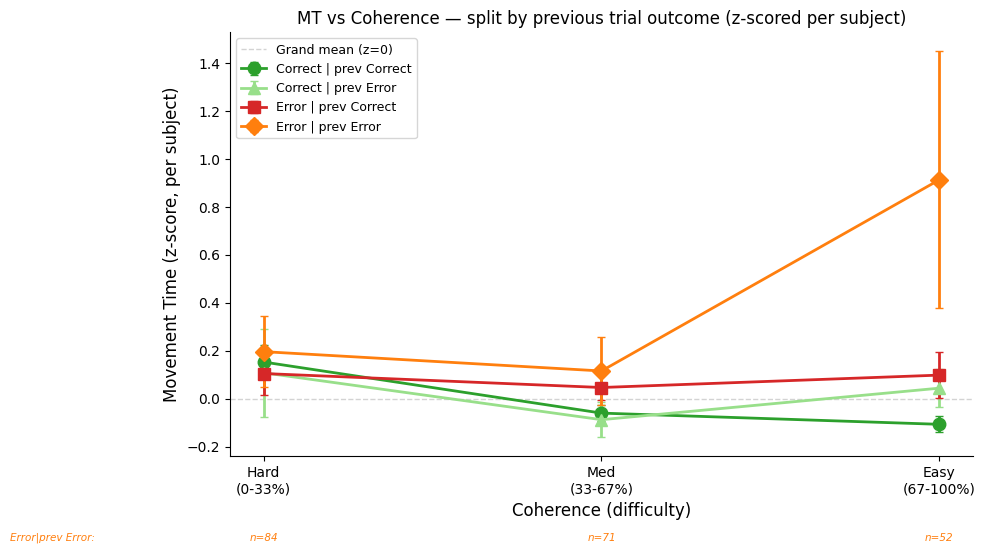

In [30]:
fig51, ax = plt.subplots(figsize=(10, 6))
BIN_X_LABELS = ['Hard\n(0-33%)', 'Med\n(33-67%)', 'Easy\n(67-100%)']

combos = [
    (True,  True,  'Correct | prev Correct', '#2ca02c', '-', 'o'),
    (True,  False, 'Correct | prev Error',   '#98df8a', '-', '^'),
    (False, True,  'Error | prev Correct',   '#d62728', '-', 's'),
    (False, False, 'Error | prev Error',     '#ff7f0e', '-', 'D'),
]
main_df = mv5[mv5.Name != 'GP4-85'].dropna(subset=['PrevChoiceCorrect'])

for curr_corr, prev_corr, label, color, ls, marker in combos:
    sub = main_df[(main_df.ChoiceCorrect == (1 if curr_corr else 0)) &
                  (main_df.PrevChoiceCorrect == prev_corr)]
    if len(sub) < 10:
        continue
    _, agg = sess_mean_sem(sub, ['Bin'], value_col='MT_z')
    ax.errorbar(BIN_MIDS_PCT[agg.Bin], agg['mean'], yerr=agg['sem'],
                fmt=f'{marker}{ls}', capsize=3, linewidth=2, markersize=9,
                color=color, label=label, zorder=3)

ax.axhline(0, color='lightgrey', linewidth=1.0, linestyle='--', zorder=0, label='Grand mean (z=0)')

# n= annotations for Error | prev Error condition
sub_ee = main_df[(main_df.ChoiceCorrect == 0) & (main_df.PrevChoiceCorrect == False)]
ee_counts = sub_ee.groupby('Bin').size()
trans = ax.get_xaxis_transform()
for b in range(3):
    n = int(ee_counts.get(b, 0))
    ax.text(BIN_MIDS_PCT[b], -0.18, f'n={n:,}', ha='center', va='top',
            fontsize=7.5, color='#ff7f0e', transform=trans, fontstyle='italic')
ax.text(0.0, -0.18, 'Error|prev Error:', ha='right', va='top',
        fontsize=7.5, color='#ff7f0e', transform=trans, fontstyle='italic')

ax.set_xlabel('Coherence (difficulty)', fontsize=12)
ax.set_ylabel('Movement Time (z-score, per subject)', fontsize=12)
ax.set_xticks(BIN_MIDS_PCT); ax.set_xticklabels(BIN_X_LABELS)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(fontsize=9, loc='upper left')
ax.set_title('MT vs Coherence — split by previous trial outcome (z-scored per subject)', fontsize=12)
fig51.tight_layout(rect=[0, 0.05, 1, 1])
fig51.savefig("mt_by_prev_outcome.png", dpi=150, bbox_inches='tight')
plt.show()


**Section 5.1 — key observations**

- Trials preceded by an error show longer MT than trials preceded by a correct response across all current-trial outcomes, consistent with a post-error cautionary adjustment.
- The post-error MT elevation is largest on easy (high-coherence) trials, where an error is most unexpected and most likely to trigger belief updating.
- GP4-85 (faint lines) shows qualitatively similar ordering but compressed MT range, consistent with the lower overall MT noted in Section 1.3.


## 5.2 Confidence-scaled updating: previous difficulty × previous outcome

For each current trial, MT is grouped by `PrevDVstr` (Easy/Med/Hard) × `PrevChoiceCorrect` (True/False). Mean MT is shown for each of the 6 combinations. A second panel restricts to hard current trials (Bin 0), where the expected modulation is strongest.

Method: per-session average of averages, error bars = SEM across sessions.

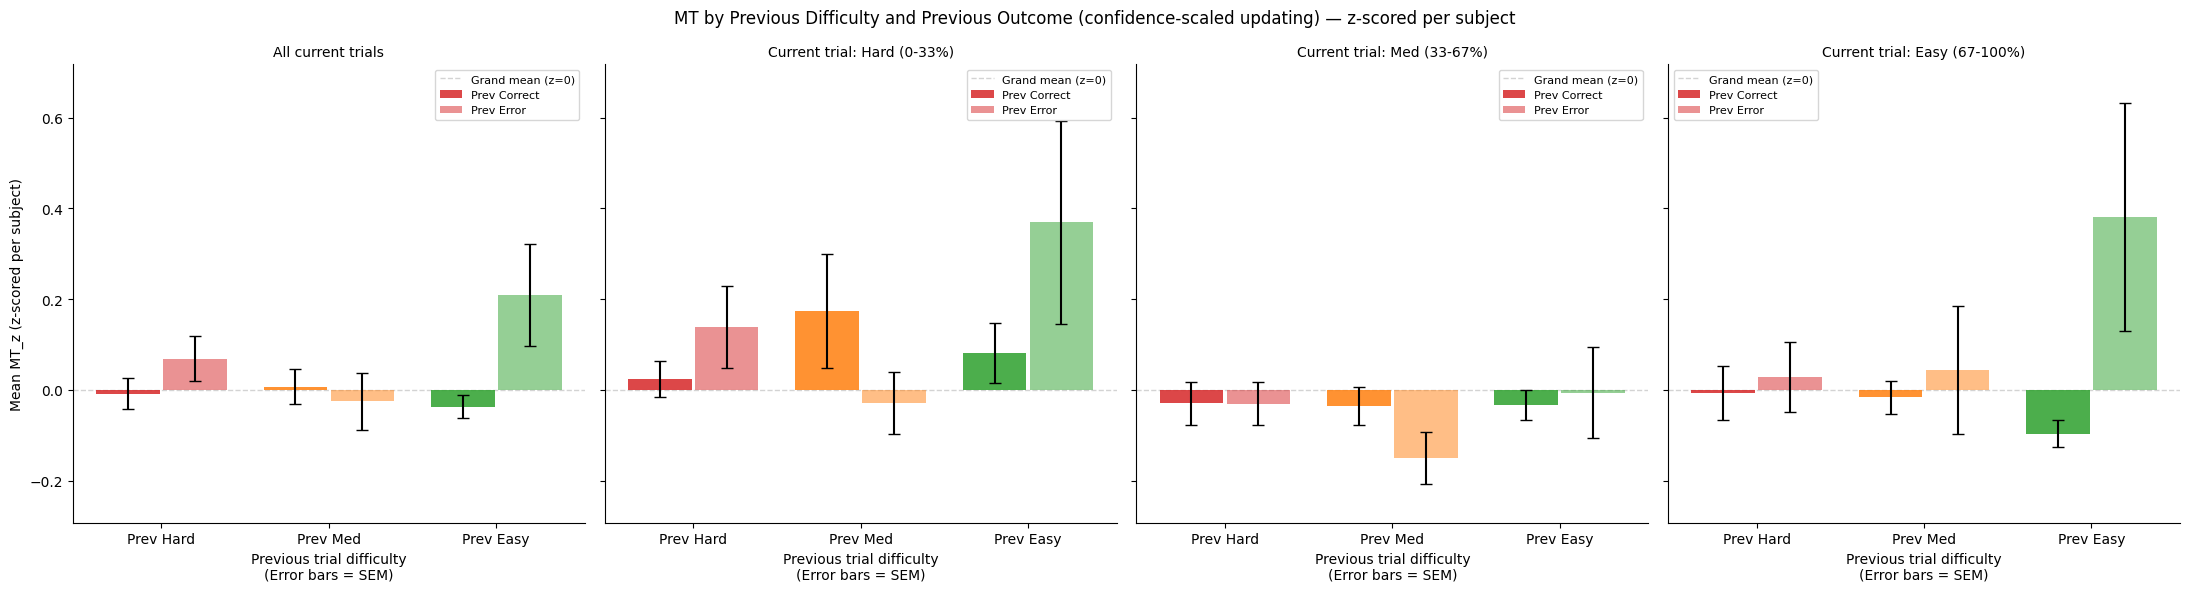

In [31]:
diff_order  = ['Hard', 'Med', 'Easy']
diff_colors = {'Hard': '#d62728', 'Med': '#ff7f0e', 'Easy': '#2ca02c'}
mv5_nonan   = mv5.dropna(subset=['PrevDVstr', 'PrevChoiceCorrect'])

panel_configs = [
    (mv5_nonan,                   'All current trials'),
    (mv5_nonan[mv5_nonan.Bin==0], 'Current trial: Hard (0-33%)'),
    (mv5_nonan[mv5_nonan.Bin==1], 'Current trial: Med (33-67%)'),
    (mv5_nonan[mv5_nonan.Bin==2], 'Current trial: Easy (67-100%)'),
]

# ── Pre-compute global y-limits across all panels ────────────────────────────
all_means, all_sems = [], []
for sub_df, _ in panel_configs:
    for prev_corr in [True, False]:
        for dstr in diff_order:
            sub = sub_df[(sub_df.PrevDVstr == dstr) & (sub_df.PrevChoiceCorrect == prev_corr)]
            if len(sub) >= 5:
                _, agg = sess_mean_sem(sub, ['PrevDVstr'], value_col='MT_z')
                row = agg[agg.PrevDVstr == dstr]
                if len(row):
                    m = float(row['mean'].iloc[0])
                    s = float(row['sem'].iloc[0])
                    all_means.append(m); all_sems.append(s)
if all_means:
    y_lo = min(m - s for m, s in zip(all_means, all_sems))
    y_hi = max(m + s for m, s in zip(all_means, all_sems))
    pad  = 0.10 * (y_hi - y_lo)
    YLIM = (y_lo - pad, y_hi + pad)
else:
    YLIM = (-1.5, 1.5)

fig52, axes52 = plt.subplots(1, 4, figsize=(22, 6), sharey=True)
fig52.suptitle('MT by Previous Difficulty and Previous Outcome (confidence-scaled updating) — z-scored per subject',
               fontsize=12)

for panel_idx, (ax, (sub_df, title_suffix)) in enumerate(zip(axes52, panel_configs)):
    for prev_corr, bar_label, bar_alpha in [(True, 'Prev Correct', 0.85), (False, 'Prev Error', 0.50)]:
        means, sems, x_pos = [], [], []
        for di, dstr in enumerate(diff_order):
            sub = sub_df[(sub_df.PrevDVstr == dstr) & (sub_df.PrevChoiceCorrect == prev_corr)]
            if len(sub) < 5:
                means.append(np.nan); sems.append(np.nan)
            else:
                _, agg = sess_mean_sem(sub, ['PrevDVstr'], value_col='MT_z')
                row = agg[agg.PrevDVstr == dstr]
                means.append(float(row['mean'].iloc[0]) if len(row) else np.nan)
                sems.append(float(row['sem'].iloc[0])   if len(row) else np.nan)
            x_pos.append(di)
        offset = -0.2 if prev_corr else 0.2
        ax.bar([x + offset for x in x_pos], means, width=0.38,
               color=[diff_colors[d] for d in diff_order],
               alpha=bar_alpha, label=bar_label, zorder=3)
        ax.errorbar([x + offset for x in x_pos], means, yerr=sems,
                    fmt='none', ecolor='black', capsize=4, linewidth=1.5, zorder=4)

    ax.axhline(0, color='lightgrey', linewidth=1.0, linestyle='--', zorder=0, label='Grand mean (z=0)')
    ax.set_xticks(range(len(diff_order)))
    ax.set_xticklabels(['Prev Hard', 'Prev Med', 'Prev Easy'])
    ax.set_xlabel('Previous trial difficulty\n(Error bars = SEM)', fontsize=10)
    ax.set_ylim(YLIM)
    if panel_idx == 0:
        ax.set_ylabel('Mean MT_z (z-scored per subject)', fontsize=10)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.set_title(title_suffix, fontsize=10)
    ax.legend(fontsize=8)

fig52.tight_layout()
fig52.savefig("mt_prev_difficulty_outcome.png", dpi=150, bbox_inches='tight')
plt.show()


**Section 5.2 — key observations**

- Current-trial MT is systematically higher following an error than following a correct response, regardless of the previous trial's difficulty — indicating a general post-error cautionary signal.
- The modulation is amplified when the previous trial was easy: an error on an easy trial (high expected correctness) produces the largest MT increase on the subsequent trial, consistent with confidence-scaled belief updating.
- Restricting to hard current trials (right panel) confirms that history-dependent modulation persists when current difficulty is held constant.


## 5.3 Win-stay / Lose-shift signature in MT

Each trial is classified into four categories using `Stay` (same direction as previous) and `PrevChoiceCorrect`:

- **Win-stay**: previous correct, same choice
- **Win-shift**: previous correct, different choice
- **Lose-stay**: previous error, same choice
- **Lose-shift**: previous error, different choice

A second panel normalises MT against `StayBaseline` (per-session per-bin mean MT) to remove the trivial effect of difficulty on stay probability.

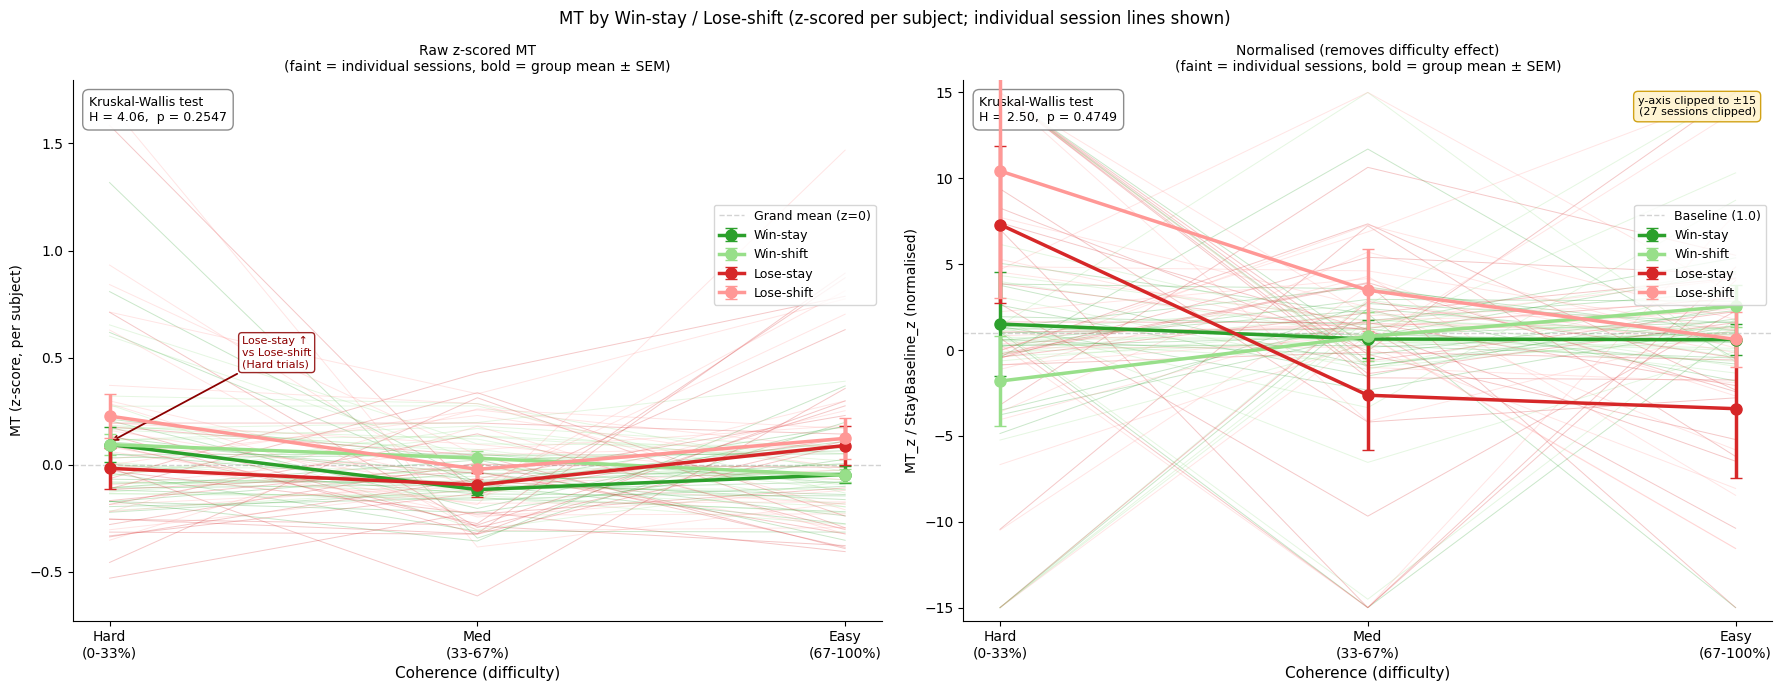

In [32]:
from scipy import stats as sp_stats

mv5_ws = mv5.dropna(subset=['Stay', 'PrevChoiceCorrect']).copy()
mv5_ws['MT_norm_z'] = mv5_ws['MT_z'] / mv5_ws['StayBaseline_z'].replace(0, np.nan)

NORM_CLIP = 15.0   # clip normalized panel to [-15, 15]

conditions = {
    'Win-stay':  (mv5_ws.PrevChoiceCorrect == True)  & (mv5_ws.Stay == True),
    'Win-shift': (mv5_ws.PrevChoiceCorrect == True)  & (mv5_ws.Stay == False),
    'Lose-stay': (mv5_ws.PrevChoiceCorrect == False) & (mv5_ws.Stay == True),
    'Lose-shift':(mv5_ws.PrevChoiceCorrect == False) & (mv5_ws.Stay == False),
}
cat_colors = {'Win-stay': '#2ca02c', 'Win-shift': '#98df8a',
              'Lose-stay': '#d62728', 'Lose-shift': '#ff9896'}
cat_list = list(conditions.keys())

fig53, axes53 = plt.subplots(1, 2, figsize=(18, 7))
fig53.suptitle('MT by Win-stay / Lose-shift (z-scored per subject; individual session lines shown)', fontsize=12)

for panel_idx, (ax, value_col, y_label, title_sfx) in enumerate(zip(
        axes53,
        ['MT_z', 'MT_norm_z'],
        ['MT (z-score, per subject)', 'MT_z / StayBaseline_z (normalised)'],
        ['Raw z-scored MT', 'Normalised (removes difficulty effect)'])):

    cat_session_vals = {cat: [] for cat in cat_list}
    n_clipped_total  = 0

    for cat, mask in conditions.items():
        sub = mv5_ws[mask].copy()
        sess_grand = sub.groupby(SESSION_KEY)[value_col].mean()
        cat_session_vals[cat] = sess_grand.values.tolist()

        sess_bin = sub.groupby(SESSION_KEY + ['Bin'])[value_col].mean().reset_index()

        if panel_idx == 1:
            # count sessions that get clipped (any bin value outside ±NORM_CLIP)
            for _, sg in sess_bin.groupby(SESSION_KEY):
                if (sg[value_col].abs() > NORM_CLIP).any():
                    n_clipped_total += 1

        for _, sg in sess_bin.groupby(SESSION_KEY):
            bvals = sg.set_index('Bin')[value_col]
            xs    = BIN_MIDS_PCT[bvals.index]
            y_plot = bvals.values
            if panel_idx == 1:
                y_plot = np.clip(y_plot, -NORM_CLIP, NORM_CLIP)
            ax.plot(xs, y_plot, '-', color=cat_colors[cat],
                    linewidth=0.7, alpha=0.25, zorder=1)

        _, agg = sess_mean_sem(sub, ['Bin'], value_col=value_col)
        ax.errorbar(BIN_MIDS_PCT[agg.Bin], agg['mean'], yerr=agg['sem'],
                    fmt='-o', color=cat_colors[cat], linewidth=2.5, markersize=8,
                    capsize=4, label=cat, zorder=4)

    # Kruskal-Wallis — full name, larger box
    kw_vals = [v for v in cat_session_vals.values() if len(v) >= 2]
    if len(kw_vals) == 4:
        H, p_kw = sp_stats.kruskal(*kw_vals)
        kw_str = f'Kruskal-Wallis test\nH = {H:.2f},  p = {p_kw:.4f}'
        ax.text(0.02, 0.97, kw_str, transform=ax.transAxes, fontsize=9, va='top',
                bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='grey', alpha=0.9))

    if panel_idx == 1 and n_clipped_total > 0:
        ax.text(0.98, 0.97,
                f'y-axis clipped to ±{NORM_CLIP:.0f}\n({n_clipped_total} sessions clipped)',
                transform=ax.transAxes, fontsize=8, va='top', ha='right',
                bbox=dict(boxstyle='round,pad=0.4', fc='#fff3cd', ec='#cc9900', alpha=0.9))
        ax.set_ylim(-NORM_CLIP * 1.05, NORM_CLIP * 1.05)

    # ── Arrow annotation at Hard coherence: Lose-stay vs Lose-shift divergence ─
    if panel_idx == 0:
        hard_x = BIN_MIDS_PCT[0]
        sub_ls = mv5_ws[conditions['Lose-stay']]
        sub_lf = mv5_ws[conditions['Lose-shift']]
        _, agg_ls = sess_mean_sem(sub_ls, ['Bin'], value_col=value_col)
        _, agg_lf = sess_mean_sem(sub_lf, ['Bin'], value_col=value_col)
        ls_hard = agg_ls[agg_ls.Bin == 0]['mean']
        lf_hard = agg_lf[agg_lf.Bin == 0]['mean']
        if len(ls_hard) and len(lf_hard):
            mid_y = (float(ls_hard.iloc[0]) + float(lf_hard.iloc[0])) / 2
            ax.annotate('Lose-stay ↑\nvs Lose-shift\n(Hard trials)',
                        xy=(hard_x, mid_y), xytext=(hard_x + 12, mid_y + 0.35),
                        fontsize=8, color='darkred',
                        arrowprops=dict(arrowstyle='->', color='darkred', lw=1.3),
                        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='darkred', alpha=0.85))

    ref = 0 if 'norm' not in value_col else 1.0
    ax.axhline(ref, color='lightgrey', linewidth=1.0, linestyle='--', zorder=0,
               label='Grand mean (z=0)' if ref == 0 else 'Baseline (1.0)')
    ax.set_xlabel('Coherence (difficulty)', fontsize=11)
    ax.set_ylabel(y_label, fontsize=10)
    ax.set_xticks(BIN_MIDS_PCT)
    ax.set_xticklabels(['Hard\n(0-33%)', 'Med\n(33-67%)', 'Easy\n(67-100%)'])
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    # Place legend outside plot area to avoid overlap with session lines
    ax.legend(fontsize=9, loc='upper right', bbox_to_anchor=(1.0, 0.78))
    ax.set_title(f'{title_sfx}\n(faint = individual sessions, bold = group mean ± SEM)', fontsize=10)

fig53.tight_layout()
fig53.savefig("mt_win_stay_lose_shift.png", dpi=150, bbox_inches='tight')
plt.show()


**Section 5.3 — key observations**

- Lose-stay trials show the longest MT across all coherence bins, suggesting that persisting with a losing strategy is accompanied by elevated deliberation during the run.
- Lose-shift trials show shorter MT than Lose-stay, consistent with a decisive strategy update that resolves uncertainty before movement begins.
- After normalisation by the per-session per-bin baseline, the Lose-stay elevation is preserved, confirming it is not simply a consequence of harder trials having both higher stay rates and longer MT.


## 5.4 Streak effects on MT

`PrevOutcomeCount` is the signed consecutive outcome streak ending at the previous trial: positive = consecutive correct, negative = consecutive errors. Values beyond ±5 are pooled into ±5+ bins to avoid small-n cells.

Method: per-session average of averages, error bars = SEM across sessions. Dashed grey line = grand mean MT.

*Positive values = consecutive correct trials; negative = consecutive errors.*

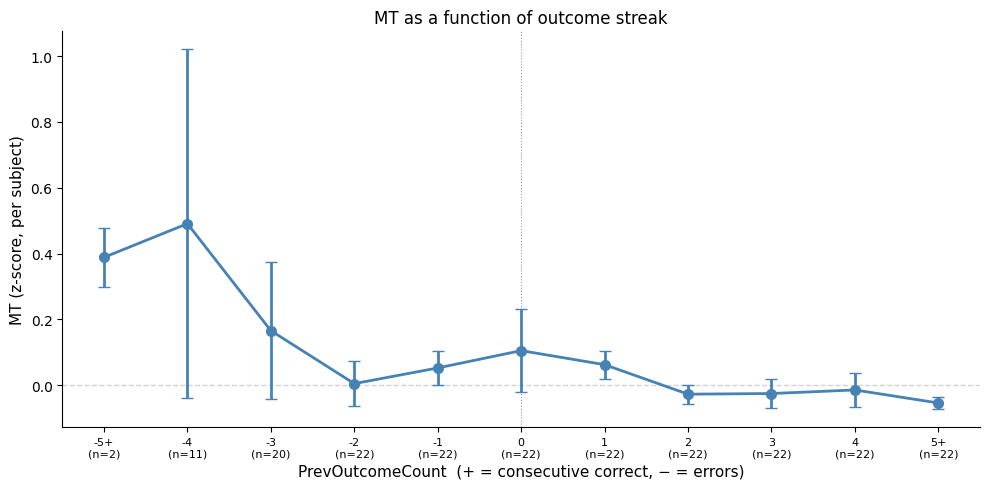

In [33]:
STREAK_CLIP = 5
mv5_str = mv5.dropna(subset=['PrevOutcomeCount', 'MT_z']).copy()
mv5_str['StreakBin'] = mv5_str['PrevOutcomeCount'].clip(-STREAK_CLIP, STREAK_CLIP).astype(int)
streak_vals = list(range(-STREAK_CLIP, STREAK_CLIP + 1))

mt_z_means, mt_z_sems = [], []
n_sess_per_bin        = []
for sv in streak_vals:
    sub   = mv5_str[mv5_str.StreakBin == sv]
    sm_mt = sub.groupby(SESSION_KEY)['MT_z'].mean()
    n_sess_per_bin.append(len(sm_mt))
    if len(sm_mt) < 2:
        mt_z_means.append(np.nan); mt_z_sems.append(np.nan)
    else:
        mt_z_means.append(sm_mt.mean())
        mt_z_sems.append(sm_mt.std(ddof=1) / np.sqrt(len(sm_mt)))

fig54, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(streak_vals, mt_z_means, yerr=mt_z_sems,
            fmt='-o', color='steelblue', linewidth=2, markersize=7,
            capsize=4, zorder=3)
ax.axhline(0, color='lightgrey', linewidth=1.0, linestyle='--', zorder=0)
ax.axvline(0, color='black', linewidth=0.8, linestyle=':', alpha=0.4)

x_tick_labels = []
for sv, ns in zip(streak_vals, n_sess_per_bin):
    lbl = f'{sv}+' if abs(sv) == STREAK_CLIP else str(sv)
    lbl += f'\n(n={ns})'
    x_tick_labels.append(lbl)
ax.set_xticks(streak_vals)
ax.set_xticklabels(x_tick_labels, fontsize=8)
ax.set_xlabel('PrevOutcomeCount  (+ = consecutive correct, − = errors)', fontsize=11)
ax.set_ylabel('MT (z-score, per subject)', fontsize=11)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.set_title('MT as a function of outcome streak', fontsize=12)
fig54.tight_layout()
fig54.savefig("mt_streak.png", dpi=150, bbox_inches='tight')
plt.show()


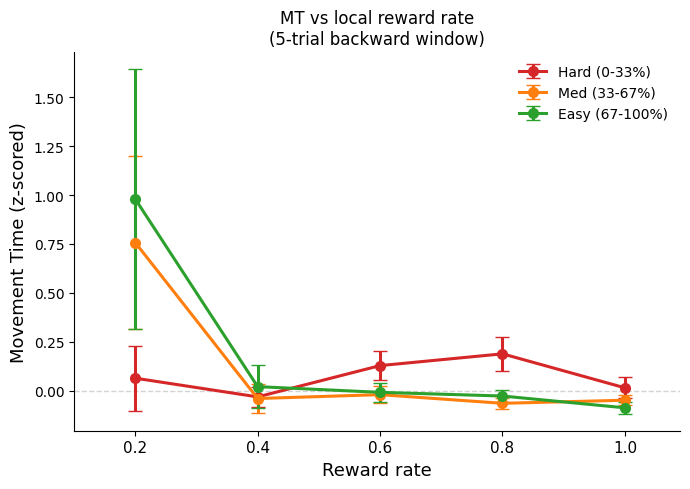

In [34]:
# ── 5.4b Reward Rate vs Movement Time (panel-H style) ───────────────────────
# Local reward rate (5-trial backward window) binned at 0-20 … 80-100 %.
# X-axis tick positions = bin right edges (0.2, 0.4, … 1.0), matching
# the reference figure style.

RR_EDGES  = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.01])
RR_RIGHT  = np.array([0.2, 0.4, 0.6, 0.8, 1.0])   # tick positions (right edges)
RR_LABELS = ['0.2', '0.4', '0.6', '0.8', '1.0']

coh_colors  = {0: '#d62728', 1: '#ff7f0e', 2: '#2ca02c'}
coh_lbls    = {0: f'Hard ({BIN_LABELS[0]})',
               1: f'Med ({BIN_LABELS[1]})',
               2: f'Easy ({BIN_LABELS[2]})'}

mv5_rr = mv5.dropna(subset=['RewardRate5', 'MT_z']).copy()
mv5_rr['RR_bin'] = pd.cut(mv5_rr['RewardRate5'], bins=RR_EDGES,
                           labels=False, include_lowest=True)
mv5_rr = mv5_rr.dropna(subset=['RR_bin'])
mv5_rr['RR_bin'] = mv5_rr['RR_bin'].astype(int)

fig_rr, ax = plt.subplots(figsize=(7, 5))

for coh_bin in [0, 1, 2]:
    sub_c = mv5_rr[mv5_rr.Bin == coh_bin]
    _, rr_agg = sess_mean_sem(sub_c, ['RR_bin'], value_col='MT_z')
    xs = RR_RIGHT[rr_agg.RR_bin]
    ax.errorbar(xs, rr_agg['mean'], yerr=rr_agg['sem'],
                fmt='-o', color=coh_colors[coh_bin], linewidth=2.2,
                markersize=7, capsize=5, label=coh_lbls[coh_bin], zorder=3)

ax.axhline(0, color='lightgrey', linewidth=1.0, linestyle='--', zorder=0)
ax.set_xticks(RR_RIGHT)
ax.set_xticklabels(RR_LABELS, fontsize=11)
ax.set_xlim(0.1, 1.09)
ax.set_xlabel('Reward rate', fontsize=13)
ax.set_ylabel('Movement Time (z-scored)', fontsize=13)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(fontsize=10, loc='upper right', frameon=False)
ax.set_title('MT vs local reward rate\n(5-trial backward window)', fontsize=12)
fig_rr.tight_layout()
fig_rr.savefig("mt_vs_reward_rate.png", dpi=150, bbox_inches='tight')
plt.show()


**Section 5.4 — key observations**

- MT shows a monotonic decrease across positive streak values (consecutive correct trials), indicating that ongoing success gradually reduces motor deliberation — consistent with a behavioral confidence-building process.
- Long negative streaks (consecutive errors) are associated with elevated MT, consistent with increasing uncertainty or a cautious strategy following persistent failure.
- The streak effect is graded rather than step-like, suggesting continuous integration of recent trial history rather than a binary switch.


## 5.5 Accuracy as a function of movement time

Mirrors the decision-time accuracy plots in the published literature. Trials are grouped by MT into bins; within each bin the fraction of correct choices is computed (per-session average of averages). Three lines show Hard / Medium / Easy coherence.

A monotonic decrease in accuracy with MT is expected: fast runs tend to be confident and correct; slow runs reflect hesitation and more errors. The steepness of this decline should depend on coherence.

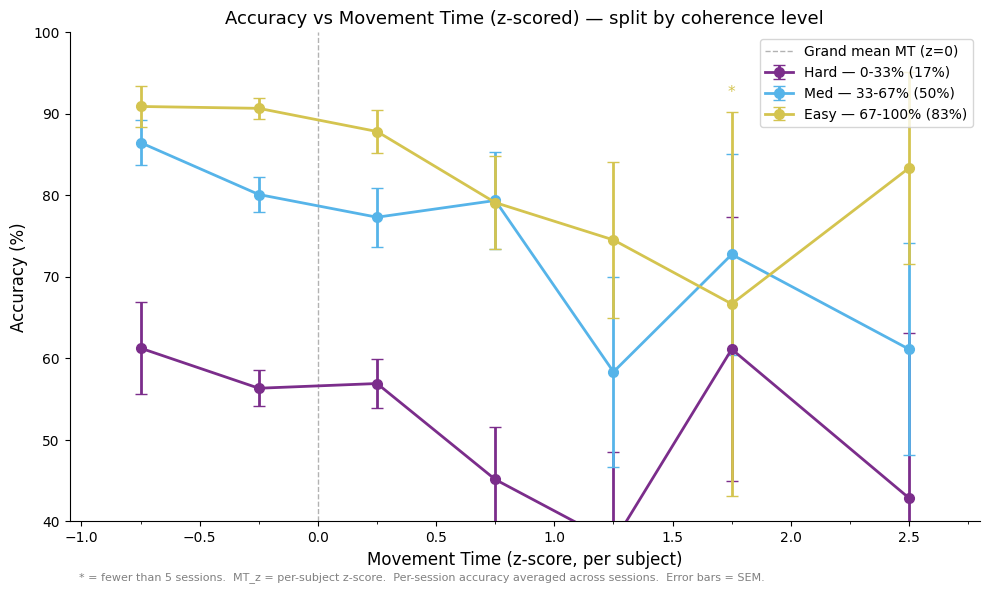

In [35]:
# ── 5.5 Accuracy vs Movement Time (z-scored) ────────────────────────────────
MT_Z_EDGES = np.array([-3.0, -2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 3.0])
MT_Z_MIDS  = (MT_Z_EDGES[:-1] + MT_Z_EDGES[1:]) / 2

mv5_acc = mv5.dropna(subset=['MT_z', 'ChoiceCorrect']).copy()
mv5_acc['MT_z_bin'] = pd.cut(mv5_acc['MT_z'], bins=MT_Z_EDGES,
                              labels=False, include_lowest=True)
mv5_acc = mv5_acc.dropna(subset=['MT_z_bin'])
mv5_acc['MT_z_bin'] = mv5_acc['MT_z_bin'].astype(int)

bin_colors = {0: '#7b2d8b', 1: '#56b4e9', 2: '#d4c44f'}
bin_labels = {0: f'Hard — {BIN_LABELS[0]} ({BIN_MIDS_PCT[0]:.0f}%)',
              1: f'Med — {BIN_LABELS[1]} ({BIN_MIDS_PCT[1]:.0f}%)',
              2: f'Easy — {BIN_LABELS[2]} ({BIN_MIDS_PCT[2]:.0f}%)'}

fig55, ax = plt.subplots(figsize=(10, 6))
all_xs = []

for coh_bin in [0, 1, 2]:
    sub_coh  = mv5_acc[mv5_acc.Bin == coh_bin]
    sess_acc = (sub_coh.groupby(SESSION_KEY + ['MT_z_bin'])['ChoiceCorrect']
                .mean().reset_index().rename(columns={'ChoiceCorrect': 'acc'}))
    agg = sess_acc.groupby('MT_z_bin')['acc'].agg(
        mean='mean',
        sem=lambda x: x.std(ddof=1) / np.sqrt(len(x)),
        n='count').reset_index()

    enough = agg[agg['n'] >= 3]
    sparse = agg[(agg['n'] >= 3) & (agg['n'] < 5)]

    xs = MT_Z_MIDS[enough.MT_z_bin]
    all_xs.extend(xs.tolist())
    ax.errorbar(xs, enough['mean'] * 100, yerr=enough['sem'] * 100,
                fmt='-o', color=bin_colors[coh_bin], linewidth=2, markersize=7,
                capsize=4, label=bin_labels[coh_bin], zorder=3)
    for _, row in sparse.iterrows():
        x_pt = MT_Z_MIDS[int(row.MT_z_bin)]
        y_pt = row['mean'] * 100 + float(row['sem']) * 100 + 1.5
        ax.text(x_pt, y_pt, '*', ha='center', va='bottom',
                fontsize=11, color=bin_colors[coh_bin])

ax.axvline(0, color='grey', linewidth=1.0, linestyle='--', alpha=0.6,
           label='Grand mean MT (z=0)')

# Dynamic xlim — based on actual plotted data, not fixed bin edges
pad = 0.3
ax.set_xlim(min(all_xs) - pad, max(all_xs) + pad)
ax.xaxis.set_major_locator(plt.MultipleLocator(0.5))
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.25))

ax.set_xlabel('Movement Time (z-score, per subject)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(40, 100)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(fontsize=10, loc='upper right')
ax.set_title('Accuracy vs Movement Time (z-scored) — split by coherence level', fontsize=13)
ax.text(0.01, -0.12,
        '* = fewer than 5 sessions.  MT_z = per-subject z-score.  '
        'Per-session accuracy averaged across sessions.  Error bars = SEM.',
        transform=ax.transAxes, fontsize=8, color='grey')
fig55.tight_layout()
fig55.savefig("accuracy_vs_mt.png", dpi=150, bbox_inches='tight')
plt.show()


**Section 5.5 — key observations**

- Accuracy decreases monotonically with movement time across all coherence levels — fast runs are disproportionately correct, consistent with high decision confidence driving both speed and accuracy.
- The decline is steepest for easy (high-coherence) trials: a slow movement on an easy trial is a strong signal of uncertainty or a change-of-mind, whereas on hard trials slow runs are common and less diagnostic.
- The curves converge toward chance at very long MT, consistent with the interpretation that extremely slow runs reflect maximal post-decision uncertainty regardless of stimulus strength.


---
## Appendix — Glossary

## Glossary — every concept in plain language

**Trial.** One decision the mouse made: dots appear, mouse decides, mouse runs, gets reward or punishment.

**Epoch.** A named slice of one trial: `Wait Trial Start` → `Sampling` → `Movement to Lateral Port` → `Reward`/`Punishment`. Each has a duration in `epoch_time`.

**Movement Time (MT).** Duration of the Movement-to-Lateral-Port epoch.

**Coherence.** Fraction of dots agreeing on direction. `|DV|` × 100. 0% = pure noise, 100% = all dots together.

**Binning.** Grouping nearby coherences into 3 buckets so each bucket has enough trials for a stable mean.

**Trimming.** Removing extreme outliers before computing statistics. We tested 4 methods (Figure 1B); percentile (1st/99th) wins because the others either go negative or chop the legitimate right tail.

**Mean.** Sum / count. The typical value.

**SEM (Standard Error of the Mean).** `std / sqrt(n)`. **Not** the spread of the data (that's SD) — it's how precisely you've estimated the mean. Bigger sample → smaller SEM → more confident in the estimate.

**SEM across trials vs SEM across sessions.** Trials within a session aren't independent, so treating each trial as one observation overcounts samples and gives an artificially tiny SEM. Treating each session as one observation gives the honest, larger SEM.

**Cohort.** A group of mice sharing experiment / mouse line / brain target. Our data: **GP4** cohort (6 mice, L2/3 imaging). The slide showing **Rbp4_M2_1** is a different cohort entirely.

**Stalled trial.** Trial where the mouse spent >4.5 s in Sampling. Probably distracted. Flagged in red in Figure 1A, excluded from aggregates.